## SETUP

In [2]:
# ──────────────────────────────────────────────────────────────────────
# [SETUP] LIBRARIES
# ──────────────────────────────────────────────────────────────────────
!pip install -q kaggle xgboost shap imbalanced-learn

import os, json, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Statistical & Linear Algebra ──────────────────────────────────────
from scipy.stats import wasserstein_distance
from scipy.linalg import svd, eigh          

# ── Scikit-learn: Preprocessing & Selection ───────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# ── Scikit-learn: Models ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Scikit-learn: Metrics ───────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,   #imbalanced credit data
    classification_report                       #full per-class breakdown
)

# ── Dimensionality Reduction & Visualization ──────────────────────────
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ── Class Imbalance ───────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE      

# ── SHAP (interpretability) ───────────────────────────────────────────
import shap                                   

# ── PyTorch (DANN) ───────────────────────────────────────
import torch                                  
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Global Config ─────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)                       

print("Libraries loaded.")

Libraries loaded.
PyTorch version : 2.10.0+cpu
CUDA available  : False


In [3]:
# ============================================================
# [SETUP] Imports, Constants & Data Loading
# Kaggle notebook — đọc trực tiếp từ /kaggle/input/
# ============================================================
import os, glob, warnings, json
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
os.makedirs('output', exist_ok=True)

# ── Paths ─────────────────────────────────────────────────────
GERMAN_PATH = '/kaggle/input/datasets/kabure/german-credit-data-with-risk/german_credit_data.csv'
LC_PATH     = '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv'

# Verify — fail sớm nếu data chưa được attach
for path, name in [(GERMAN_PATH, 'German Credit'), (LC_PATH, 'Lending Club')]:
    if not os.path.exists(path):
        parent = os.path.dirname(path)
        avail  = os.listdir(parent) if os.path.isdir(parent) else 'DIR NOT FOUND'
        raise FileNotFoundError(
            f"❌ {name}: {path}\n"
            f"   Available in '{parent}': {avail}"
        )
    print(f"✅ {name}: {path}  ({os.path.getsize(path)/1e6:.1f} MB)")


# ══════════════════════════════════════════════════════════════
# [SETUP-1] German Credit — 1000 rows × 10 columns
# ══════════════════════════════════════════════════════════════
df_german = pd.read_csv(GERMAN_PATH, index_col=0)

# Chuẩn hoá tên cột: 'Saving accounts' → 'saving_accounts'
# Lý do: nhất quán với downstream code, tránh lỗi khoảng trắng
df_german.columns = (df_german.columns
                     .str.strip()
                     .str.lower()
                     .str.replace(' ', '_'))

# Target: 'bad' → 1, 'good' → 0
# raw target col sau khi normalize: 'risk' (không còn là 'Risk')
TARGET_COL_GERMAN = 'risk'
df_german['default'] = (
    df_german[TARGET_COL_GERMAN].str.strip().str.lower() == 'bad'
).astype(int)

assert 'default' in df_german.columns
assert df_german['default'].isin([0, 1]).all()

print("\n=== GERMAN CREDIT ===")
print(f"Shape   : {df_german.shape}")
print(f"Columns : {df_german.columns.tolist()}")
print(f"Default rate: {df_german['default'].mean():.1%} "
      f"({df_german['default'].sum()} bad / {len(df_german)} total)")
print(f"NaN:\n{df_german.isnull().sum()[df_german.isnull().sum() > 0].to_string()}")
df_german.head(3)


# ══════════════════════════════════════════════════════════════
# [SETUP-2] Lending Club — ~2.26M rows × 145 columns
# EXCLUDE: Current, In Grace Period, Does not meet policy
# LABEL 0 : Fully Paid
# LABEL 1 : Charged Off, Default, Late (31-120 days), Late (16-30 days)
# ══════════════════════════════════════════════════════════════
LABEL_MAP = {
    'Fully Paid'         : 0,
    'Charged Off'        : 1,
    'Default'            : 1,
    'Late (31-120 days)' : 1,
    'Late (16-30 days)'  : 1,
}

print("\n📥 Loading Lending Club")
df_lc = pd.read_csv(
    LC_PATH,
    # usecols   ← bỏ comment nếu cần tiết kiệm RAM: xem LC_USECOLS bên dưới
    # nrows     ← bỏ comment để test nhanh, vd: nrows=100_000
    low_memory   = False,
    on_bad_lines = 'skip',    # bỏ qua dòng lỗi format thay vì crash
)
print(f"   Raw loaded: {df_lc.shape}")

# Filter → chỉ giữ các loan có outcome xác định
df_lc = df_lc[df_lc['loan_status'].isin(LABEL_MAP)].copy()
df_lc['default'] = df_lc['loan_status'].map(LABEL_MAP)
df_lc.drop(columns=['loan_status'], inplace=True)

# Clean percentage string columns (cần cho Block 1.4 Wasserstein)
# int_rate và revol_util lưu dạng '12.50%' → float
for col in ['int_rate', 'revol_util']:
    if col in df_lc.columns and df_lc[col].dtype == object:
        df_lc[col] = (df_lc[col]
                      .str.strip()
                      .str.replace('%', '', regex=False)
                      .astype(float))

assert 'default' in df_lc.columns
assert df_lc['default'].isin([0, 1]).all()
assert 'loan_status' not in df_lc.columns

print("\n=== LENDING CLUB ===")
print(f"Shape       : {df_lc.shape}")
print(f"Default rate: {df_lc['default'].mean():.2%}")
print(f"Columns     : {df_lc.shape[1]} total")
df_lc.head(3)


# ══════════════════════════════════════════════════════════════
# [SETUP-3] Summary + Constants cho downstream blocks
# ══════════════════════════════════════════════════════════════
# Nếu cần usecols sau này (Block 1.4 semantic pairs):
LC_USECOLS = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc',
]

print(f"\n{'='*55}")
print("✅ SETUP hoàn tất:")
print(f"   df_german : {df_german.shape}  | default = {df_german['default'].mean():.1%}")
print(f"   df_lc     : {df_lc.shape} | default = {df_lc['default'].mean():.2%}")
print(f"{'='*55}")


✅ German Credit: /kaggle/input/datasets/kabure/german-credit-data-with-risk/german_credit_data.csv  (0.1 MB)
✅ Lending Club: /kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv  (1189.4 MB)

=== GERMAN CREDIT ===
Shape   : (1000, 11)
Columns : ['age', 'sex', 'job', 'housing', 'saving_accounts', 'checking_account', 'credit_amount', 'duration', 'purpose', 'risk', 'default']
Default rate: 30.0% (300 bad / 1000 total)
NaN:
saving_accounts     183
checking_account    394

📥 Loading Lending Club
   Raw loaded: (2260668, 145)

=== LENDING CLUB ===
Shape       : (1329272, 145)
Default rate: 21.61%
Columns     : 145 total

✅ SETUP hoàn tất:
   df_german : (1000, 11)  | default = 30.0%
   df_lc     : (1329272, 145) | default = 21.61%


## 1. BASELINE (train trực tiếp German Credit - No Transfer learning)

In [4]:
# ============================================================
# 1.1. Target Column Detection & Encoding
# Columns: Age, Sex, Job, Housing, Saving accounts,
#          Checking account, Credit amount, Duration, Purpose, Risk
# Target : 'Risk' | values: 'good'/'bad'
# ============================================================
import numpy as np

# ── 1.1.1. Dataset info ────────────────────────────────
print("=== Dataset Info ===")
print(f"Shape: {df_german.shape}")
print(f"Columns: {df_german.columns.tolist()}")
print(f"Dtypes:\n{df_german.dtypes}")
print(f"Missing values:\n{df_german.isnull().sum()}")

# ── 1.1.2. Target column ──────────────────────────────
KNOWN_TARGETS = ['Risk', 'risk', 'default']

TARGET_COL_GERMAN = None
for col in KNOWN_TARGETS:
    if col in df_german.columns:
        TARGET_COL_GERMAN = col
        print(f"\n→ Target found: '{col}' | dtype: {df_german[col].dtype}")
        print(f"  Values: {df_german[col].value_counts().to_dict()}")
        break

if TARGET_COL_GERMAN is None:
    raise ValueError(
        f"Không tìm thấy target column.\n"
        f"Columns hiện có: {df_german.columns.tolist()}"
    )

# ── 1.1.3. Encode target ──────────────────────────────
assert df_german[TARGET_COL_GERMAN].dtype == object, (
    f"Unexpected: target '{TARGET_COL_GERMAN}' có dtype "
    f"{df_german[TARGET_COL_GERMAN].dtype}, expected object (string).\n"
    f"Nếu bạn đổi sang dataset khác (UCI Statlog 1/2), cần update block này."
)

df_german['default'] = (
    df_german[TARGET_COL_GERMAN].str.strip().str.lower()
    .isin({'bad'})  # chỉ 'bad' = 1; 'good' = 0
    .astype(int)
)

# ── 1.1.4. Sanity check ───────────────────────────────
rate = df_german['default'].mean()
print(f"\nDefault rate: {rate:.2%}")

assert 0.20 < rate < 0.45, (f"Default rate bất thường: {rate:.2%}\n")
print("Encoding hợp lệ — 'bad'→1, 'good'→0\n")

# ── 1.1.5. Feature lists ──────────────────────────────
EXCLUDE_COLS = {TARGET_COL_GERMAN, 'default'}

german_numeric = [
    c for c in df_german.select_dtypes(include=np.number).columns
    if c not in EXCLUDE_COLS
]
german_categ = [
    c for c in df_german.select_dtypes(include='object').columns
    if c not in EXCLUDE_COLS
]

# Verify (to check leakage)
assert TARGET_COL_GERMAN not in german_numeric + german_categ
assert 'default' not in german_numeric + german_categ

print(f"Numeric features  ({len(german_numeric)}): {german_numeric}")
print(f"Categorical features ({len(german_categ)}): {german_categ}")
print(f"\n→ Expected cho German Credit dataset:")                      
print(f"  Numeric: ['Age', 'Job', 'Credit amount', 'Duration']  (Job ordinal 0-3)")
print(f"  Categ  : ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']")

=== Dataset Info ===
Shape: (1000, 11)
Columns: ['age', 'sex', 'job', 'housing', 'saving_accounts', 'checking_account', 'credit_amount', 'duration', 'purpose', 'risk', 'default']
Dtypes:
age                  int64
sex                 object
job                  int64
housing             object
saving_accounts     object
checking_account    object
credit_amount        int64
duration             int64
purpose             object
risk                object
default              int64
dtype: object
Missing values:
age                   0
sex                   0
job                   0
housing               0
saving_accounts     183
checking_account    394
credit_amount         0
duration              0
purpose               0
risk                  0
default               0
dtype: int64

→ Target found: 'risk' | dtype: object
  Values: {'good': 700, 'bad': 300}

Default rate: 30.00%
Encoding hợp lệ — 'bad'→1, 'good'→0

Numeric features  (4): ['age', 'job', 'credit_amount', 'duration']
Categor

[1.2.1] Feature Type Classification
  Continuous numeric (3): ['age', 'credit_amount', 'duration']
  Ordinal encoded    (1):   ['job']
  Categorical        (5):  ['sex', 'housing', 'saving_accounts', 'checking_account', 'purpose']

[1.2.1] Missing Values:
                  Count  Pct(%)
saving_accounts     183    18.3
checking_account    394    39.4

  → Strategy: fill NaN với 'MISSING' (categorical) / median (numeric)
    trong Block 7 Preprocessing — KHÔNG fill ở đây để tránh leakage


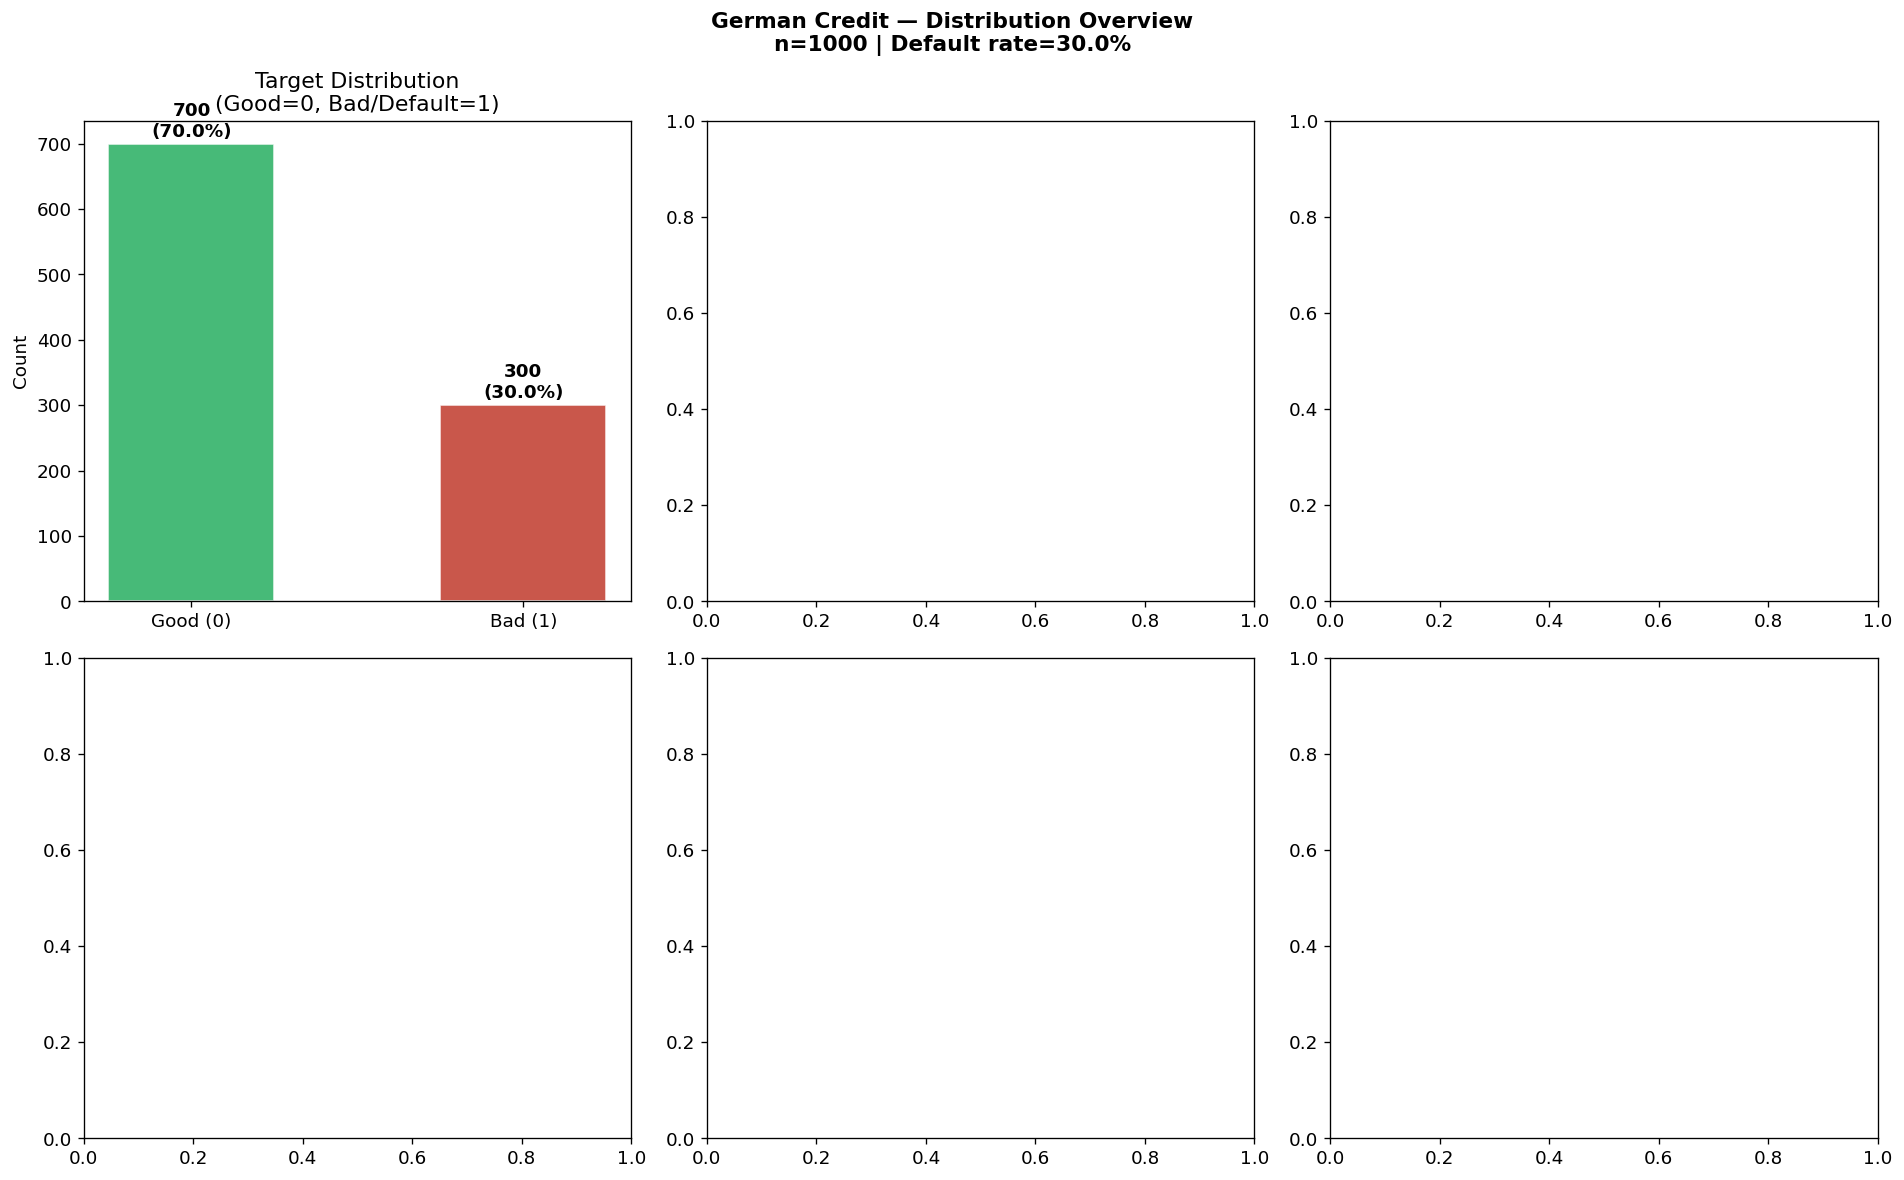

Saved: german_eda_overview.png
Saved: german_eda_correlation.png

[1.2.3] Feature Signal Ranking (for Transfer Design)

Numeric (Point-Biserial):
  duration            : +0.215  Moderate
  credit_amount       : +0.155  Moderate
  age                 : -0.091  Weak

Categorical/Ordinal (Cramér's V):
  checking_account    : 0.348  Strong
  saving_accounts     : 0.179  Moderate
  housing             : 0.127  Moderate
  purpose             : 0.081  Weak
  sex                 : 0.069  Weak
  job                 : 0.000  Weak

→ Features có signal mạnh nhất (V > 0.1 hoặc |r| > 0.1)
   sẽ được ưu tiên trong HFA projection matrix Q (target domain)


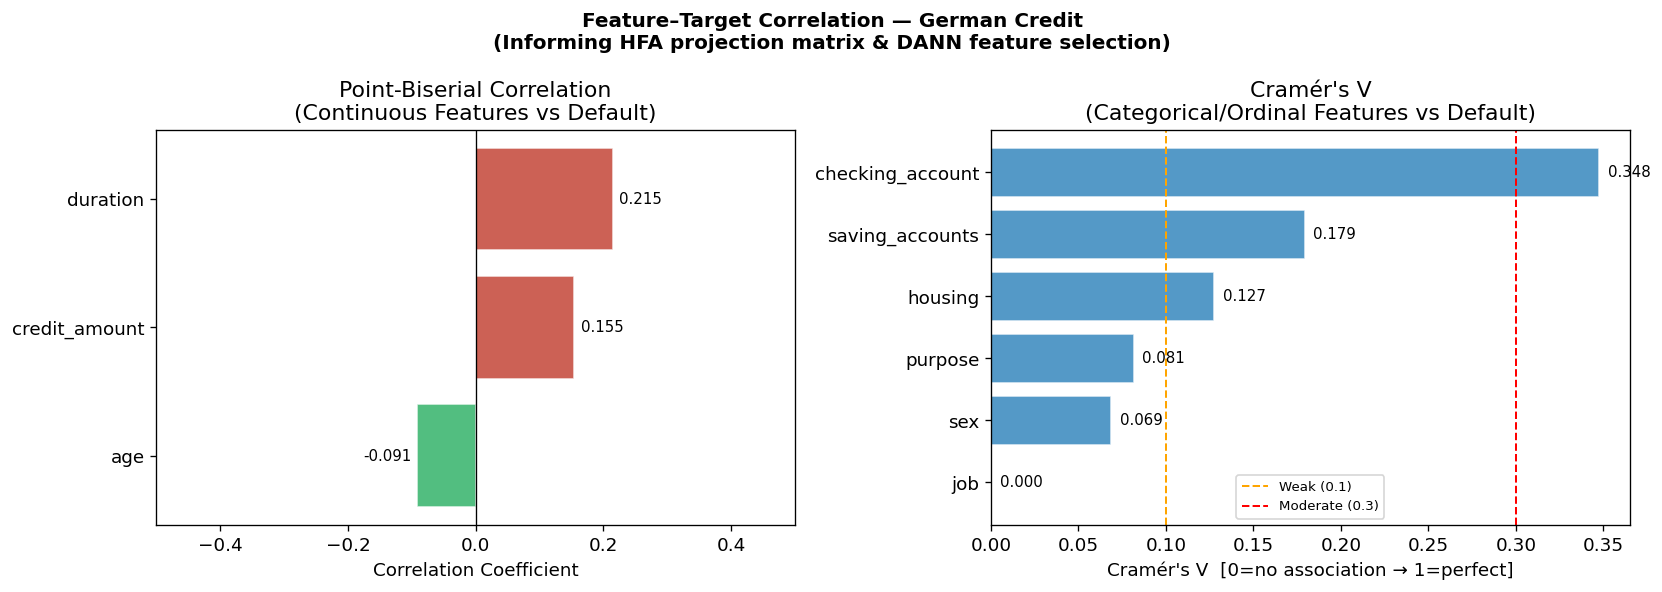

In [5]:
# ============================================================
# 1.2. EDA German Credit
# Mục đích: Hiểu phân phối & signal của từng feature
#   → Inform HFA projection matrix design (P cho target domain)
#   → Inform DANN adversarial feature selection
# ============================================================
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── 1.2.1. Feature Type Classification ──────────────────────────────
# Phân loại theo nunique()
# nunique > 10: continuous (Age ~53, Credit amount ~921, Duration ~33)
# nunique ≤ 10: ordinal encoded (Job: 0=unskilled non-res ... 3=highly skilled)
_truly_numeric = [c for c in german_numeric if df_german[c].nunique() > 10]
_encoded_num   = [c for c in german_numeric if df_german[c].nunique() <= 10]

# Summary
print("=" * 55)
print("[1.2.1] Feature Type Classification")
print("=" * 55)
print(f"  Continuous numeric ({len(_truly_numeric)}): {_truly_numeric}")
print(f"  Ordinal encoded    ({len(_encoded_num)}):   {_encoded_num}")
print(f"  Categorical        ({len(german_categ)}):  {german_categ}")

# Missing value audit (Saving/Checking có NaN)
print("\n[1.2.1] Missing Values:")
miss = df_german[german_numeric + german_categ].isnull().sum()
miss_pct = (miss / len(df_german) * 100).round(1)
miss_df = pd.DataFrame({'Count': miss, 'Pct(%)': miss_pct})
miss_df = miss_df[miss_df['Count'] > 0]
if miss_df.empty:
    print("No missing values in features")
else:
    print(miss_df.to_string())
    print(f"\n  → Strategy: fill NaN với 'MISSING' (categorical) / median (numeric)")
    print(f"    trong Block 7 Preprocessing — KHÔNG fill ở đây để tránh leakage")

# ── 1.2.2. Distribution Overview ──────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'German Credit — Distribution Overview\n'
    f'n={len(df_german)} | Default rate={df_german["default"].mean():.1%}',
    fontsize=13, fontweight='bold'
)

# Target Distribution
target_counts = df_german['default'].value_counts().sort_index()
bars = axes[0, 0].bar(
    ['Good (0)', 'Bad (1)'], target_counts.values,
    color=['#27ae60', '#c0392b'], alpha=0.85, edgecolor='white', width=0.5
)
axes[0, 0].set_title('Target Distribution\n(Good=0, Bad/Default=1)')
axes[0, 0].set_ylabel('Count')
for bar, cnt in zip(bars, target_counts.values):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        f'{cnt}\n({cnt / len(df_german) * 100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Continuous Numeric Features by Risk
_plot_pairs = [
    ('Credit amount', 'Credit Amount by Risk', 'Credit Amount (DM)', 30, axes[0, 1]),
    ('Duration',      'Loan Duration by Risk', 'Duration (months)',  20, axes[0, 2]),
    ('Age',           'Age by Risk',           'Age (years)',        20, axes[1, 0]),
]
for col, title, xlabel, bins, ax in _plot_pairs:
    if col in df_german.columns:
        for lbl, clr, name in [(0, '#27ae60', 'Good'), (1, '#c0392b', 'Bad')]:
            ax.hist(
                df_german[df_german['default'] == lbl][col],
                bins=bins, alpha=0.55, color=clr, label=name, density=True
            )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.legend()

# Categorical Features: Default Rate
# Subplot [1,1]: Checking account (ordinal signal quan trọng nhất)
if 'Checking account' in df_german.columns:
    tmp = df_german.copy()
    tmp['Checking account'] = tmp['Checking account'].fillna('No Account')
    # Sắp xếp theo mức độ tài chính tăng dần
    ca_order = ['little', 'moderate', 'rich', 'No Account']
    ca_dr = tmp.groupby('Checking account')['default'].mean()
    ca_dr = ca_dr.reindex([x for x in ca_order if x in ca_dr.index])
    
    axes[1, 1].bar(
        range(len(ca_dr)), ca_dr.values * 100,
        color=['#e74c3c' if v > df_german['default'].mean() else '#3498db'
               for v in ca_dr.values],
        alpha=0.8, edgecolor='white', width=0.6
    )
    axes[1, 1].set_xticks(range(len(ca_dr)))
    axes[1, 1].set_xticklabels(ca_dr.index, rotation=20, ha='right', fontsize=9)
    axes[1, 1].axhline(
        df_german['default'].mean() * 100, color='black',
        ls='--', lw=1.2, label=f'Avg {df_german["default"].mean()*100:.1f}%'
    )
    axes[1, 1].set_title('Default Rate\nby Checking Account Status')
    axes[1, 1].set_ylabel('Default Rate (%)')
    axes[1, 1].legend(fontsize=8)
    # Annotate bars
    for i, v in enumerate(ca_dr.values):
        axes[1, 1].text(i, v * 100 + 0.5, f'{v*100:.1f}%',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

# Subplot [1,2]: Purpose
if 'Purpose' in df_german.columns:
    pur_dr = (df_german.groupby('Purpose')['default']
              .mean()
              .sort_values(ascending=True))
    axes[1, 2].barh(pur_dr.index, pur_dr.values * 100,
                    color='#9b59b6', alpha=0.8, edgecolor='white')
    axes[1, 2].axvline(
        df_german['default'].mean() * 100, color='red',
        ls='--', lw=1.2, label=f'Avg {df_german["default"].mean()*100:.1f}%'
    )
    axes[1, 2].set_title('Default Rate by Purpose')
    axes[1, 2].set_xlabel('Default Rate (%)')
    axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/german_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: german_eda_overview.png")

# ── 1.2.3. Feature–Target Correlation ──────────────────────────────
# Tại sao cần: HFA design phải biết feature nào có predictive power
# trong target domain (German) để ưu tiên khi align với LC features

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(
    'Feature–Target Correlation — German Credit\n'
    '(Informing HFA projection matrix & DANN feature selection)',
    fontsize=12, fontweight='bold'
)

# Point-Biserial Correlation (Continuous Numeric)
# Point-biserial = Pearson khi 1 biến là binary → dùng .corr() là đúng
if _truly_numeric:
    corr_num = (
        df_german[_truly_numeric + ['default']]
        .corr()['default']
        .drop('default')
        .sort_values()
    )
    colors_num = ['#c0392b' if v > 0 else '#27ae60' for v in corr_num.values]
    axes2[0].barh(
        corr_num.index, corr_num.values,
        color=colors_num, alpha=0.8, edgecolor='white'
    )
    axes2[0].axvline(0, color='black', lw=0.8)
    axes2[0].set_title('Point-Biserial Correlation\n(Continuous Features vs Default)')
    axes2[0].set_xlabel('Correlation Coefficient')
    axes2[0].set_xlim(-0.5, 0.5)
    # Annotate values (i từ enumerate khớp với y-position barh khi dùng string labels)
    for i, (val, lbl) in enumerate(zip(corr_num.values, corr_num.index)):
        offset = 0.01 if val >= 0 else -0.01
        axes2[0].text(
            val + offset, i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9
        )

# Cramér's V (Categorical + Ordinal)
# Bias-corrected Cramér's V: phù hợp cho categorical vs binary target
# Thang: V < 0.1 = negligible, 0.1–0.3 = weak, 0.3–0.5 = moderate, > 0.5 = strong
def cramers_v(x, y):
    """Bias-corrected Cramér's V (Bergsma & Wicher, 2013)."""
    cm = pd.crosstab(x, y)
    chi2_stat = chi2_contingency(cm, correction=False)[0]
    n = cm.sum().sum()
    r, k = cm.shape
    phi2 = chi2_stat / n
    # ── Bias correction: cả numerator LẪN denominator ──
    phi2_corr = max(0.0, phi2 - (r - 1) * (k - 1) / (n - 1))  
    r_corr    = r - (r - 1) ** 2 / (n - 1)
    k_corr    = k - (k - 1) ** 2 / (n - 1)
    denom = max(min(r_corr - 1, k_corr - 1), 1e-10)
    return float(np.sqrt(phi2_corr / denom))                   

cv_vals = {}
# Categorical features (fill NaN trước khi tính V — KHÔNG lưu vào df)
for col in german_categ:
    cv_vals[col] = cramers_v(df_german[col].fillna('MISSING'), df_german['default'])
# Ordinal encoded (Job) — treat as nominal để tính V
for col in _encoded_num:
    cv_vals[col] = cramers_v(df_german[col].astype(str), df_german['default'])

cv_series = pd.Series(cv_vals).sort_values()

axes2[1].barh(cv_series.index, cv_series.values, color='#2980b9', alpha=0.8, edgecolor='white')
axes2[1].set_title("Cramér's V\n(Categorical/Ordinal Features vs Default)")
axes2[1].set_xlabel("Cramér's V  [0=no association → 1=perfect]")
axes2[1].axvline(0.1, color='orange', ls='--', lw=1.2, label='Weak (0.1)')
axes2[1].axvline(0.3, color='red',    ls='--', lw=1.2, label='Moderate (0.3)')
# Annotate values
for i, (val, lbl) in enumerate(zip(cv_series.values, cv_series.index)):
    axes2[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)
axes2[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/german_eda_correlation.png', dpi=150, bbox_inches='tight')
print("Saved: german_eda_correlation.png")

# Print correlation ranking (inform HFA/DANN design)
print("\n" + "=" * 55)
print("[1.2.3] Feature Signal Ranking (for Transfer Design)")
print("=" * 55)
print("\nNumeric (Point-Biserial):")
for feat, val in corr_num.sort_values(key=abs, ascending=False).items():
    strength = "Strong" if abs(val) > 0.3 else ("Moderate" if abs(val) > 0.1 else "Weak")
    print(f"  {feat:20s}: {val:+.3f}  {strength}")

print("\nCategorical/Ordinal (Cramér's V):")
for feat, val in cv_series.sort_values(ascending=False).items():
    strength = "Strong" if val > 0.3 else ("Moderate" if val > 0.1 else "Weak")
    print(f"  {feat:20s}: {val:.3f}  {strength}")

print("\n→ Features có signal mạnh nhất (V > 0.1 hoặc |r| > 0.1)")
print("   sẽ được ưu tiên trong HFA projection matrix Q (target domain)")

In [8]:
# ============================================================
# 1.3. Preprocessing German Credit — NO DATA LEAKAGE
# ============================================================
# Nguyên tắc thiết kế:
#   - preprocess_german() trả về X RAW (chưa scale, chưa impute numeric)
#   - StandardScaler + SimpleImputer sẽ được fit TRONG Pipeline Block 1.6+
#     → chỉ nhìn thấy train fold, không có test info thấm vào
#
# Lý do tách biệt LabelEncoder vs OrdinalEncoder:
#   - OrdinalEncoder: Checking account, Saving accounts
#     (có thứ tự rõ ràng: little < moderate < rich)
#   - LabelEncoder: các nominal categoricals còn lại
#     (Purpose, Sex, Housing → không có thứ tự)
# ============================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# ── Khai báo thứ tự tường minh cho ordinal features ──────────
# Lý do dùng map() thay OrdinalEncoder:
#   → kiểm soát chính xác integer code, dễ debug và explain
ORDINAL_SPECS = {
    'Checking account': ['MISSING', 'little', 'moderate', 'rich'],
    'Saving accounts':  ['MISSING', 'little', 'moderate', 'quite rich', 'rich'],
}
# Mapping: 'MISSING'→0 (thấp nhất), tăng dần theo mức độ tài chính

def preprocess_german(df,
                      raw_target=TARGET_COL_GERMAN,
                      processed_target='default'):
    """
    Trả về (X_raw, y, feature_names) — chưa scale, chưa impute numeric.

    Pipeline Block 1.6+ sẽ fit:
        SimpleImputer(strategy='median')  → chỉ fit trên train fold
        StandardScaler()                  → chỉ fit trên train fold

    Encoding thực hiện ở đây (trước split) vì:
        - Ordinal/LabelEncoder chỉ ánh xạ labels sang integer
        - KHÔNG tính statistics từ distribution → không leakage
        - German Credit là closed dataset: không có unseen categories
          (khác production where unseen categories are possible)
    """
    exclude = {raw_target, processed_target}
    df_p = df.drop(columns=[c for c in exclude if c in df.columns]).copy()
    y    = df[processed_target].values

    # ── 1.5.1. Ordinal encoding (giữ nguyên thứ tự ý nghĩa) ─
    for col, order in ORDINAL_SPECS.items():
        if col not in df_p.columns:
            continue
        df_p[col] = df_p[col].fillna('MISSING')
        order_map = {cat: idx for idx, cat in enumerate(order)}
        df_p[col] = df_p[col].map(order_map)
        # Giá trị không nằm trong order → NaN → Pipeline imputer xử lý
        n_unknown = df_p[col].isna().sum()
        if n_unknown > 0:
            print(f"'{col}': {n_unknown} unknown value(s) → NaN")

    # ── 1.5.2. LabelEncoder cho nominal categoricals còn lại ─
    # Note: fit trên full data là OK với German Credit (closed dataset)
    # KHÔNG dùng cách này trong production (unseen categories sẽ crash)
    for col in df_p.select_dtypes(include='object').columns:
        df_p[col] = df_p[col].fillna('MISSING')
        le = LabelEncoder()
        df_p[col] = le.fit_transform(df_p[col].astype(str))

    # ── 1.5.3. Numeric NaN — KHÔNG fillna ở đây ──────────────
    # fillna(median) trước split = data leakage:
    #   median tính trên cả test set → thấm vào fill value của train
    # Fix: chuyển hoàn toàn vào Pipeline với SimpleImputer(strategy='median')
    # (fit chỉ trên train fold trong cross-validation)

    # ── Assertions bảo vệ target leak ─────────────────────────
    assert processed_target not in df_p.columns, \
        f"TARGET LEAK: '{processed_target}' vẫn còn trong features!"
    assert raw_target not in df_p.columns, \
        f"RAW TARGET LEAK: '{raw_target}' vẫn còn trong features!"

    feat_names = df_p.columns.tolist()
    X          = df_p.values.astype(float)
    nan_count  = int(np.isnan(X).sum())

    print(f"   Preprocessed: X.shape={X.shape}, y.shape={y.shape}")
    print(f"   Features ({len(feat_names)}): {feat_names}")
    print(f"   NaN còn lại (Pipeline sẽ impute): {nan_count}")
    print(f"   Default rate: {y.mean():.2%}")
    return X, y, feat_names


X_gm_raw, y_gm, feat_names_gm = preprocess_german(df_german)

# ── Train/Test Split ─────────────────────────────────
# Hold-out set bất biến → so sánh Baseline/HFA/DANN/FDAT
# trên CÙNG test set (apples-to-apples evaluation)
# FDAT paper Section 4.2: 80% train / 20% test, stratified
X_train_gm, X_test_gm, y_train_gm, y_test_gm = train_test_split(
    X_gm_raw, y_gm,
    test_size    = 0.20,
    stratify     = y_gm,      # giữ 30% bad rate trong cả train lẫn test
    random_state = SEED
)

print(f"\nTrain : {X_train_gm.shape}  | default rate: {y_train_gm.mean():.2%}")
print(f"Test  : {X_test_gm.shape}   | default rate: {y_test_gm.mean():.2%}")
print(f"\nHold-out test set đã lưu — dùng chung cho tất cả model:")
print(f" Baseline (LogReg/RF) → HFA → DANN → FDAT comparison")

   Preprocessed: X.shape=(1000, 9), y.shape=(1000,)
   Features (9): ['age', 'sex', 'job', 'housing', 'saving_accounts', 'checking_account', 'credit_amount', 'duration', 'purpose']
   NaN còn lại (Pipeline sẽ impute): 0
   Default rate: 30.00%

Train : (800, 9)  | default rate: 30.00%
Test  : (200, 9)   | default rate: 30.00%

Hold-out test set đã lưu — dùng chung cho tất cả model:
 Baseline (LogReg/RF) → HFA → DANN → FDAT comparison


In [9]:
# ============================================================
# 1.4. Baseline Models — 5-Fold CV + Hold-out Test Set
# ============================================================
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics         import (roc_auc_score, confusion_matrix,
                                      roc_curve, brier_score_loss)
from xgboost import XGBClassifier
import plotly.graph_objects as go
import pandas as pd, numpy as np

# ── Scale Pos Weight cho XGBoost ──────────────────────────────
neg, pos = np.bincount(y_train_gm.astype(int))
spw      = neg / pos
print(f"Class balance → Good: {neg}, Bad: {pos}, SPW: {spw:.2f}")

# ── Pipeline Definitions ───────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, max_iter=1000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=SEED
        ))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=8,
            class_weight='balanced',
            random_state=SEED, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=200, max_depth=4,
            learning_rate=0.05,
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=SEED
        ))
    ]),
}


def find_optimal_threshold_ks(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks_idx = np.argmax(tpr - fpr)
    return float(thresholds[ks_idx]), float(tpr[ks_idx] - fpr[ks_idx])


def evaluate(name, y_true, y_prob, threshold=None):
    if threshold is None:
        threshold, ks_stat = find_optimal_threshold_ks(y_true, y_prob)
    else:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ks_stat = float(np.max(tpr - fpr))

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        'Model'      : name,
        'AUC'        : round(roc_auc_score(y_true, y_prob), 4),
        'KS'         : round(ks_stat, 4),
        'Brier Score': round(brier_score_loss(y_true, y_prob), 4),
        'Sensitivity': round(tp / (tp + fn) if (tp + fn) > 0 else 0.0, 4),
        'Specificity': round(tn / (tn + fp) if (tn + fp) > 0 else 0.0, 4),
        'Accuracy'   : round((tp + tn) / len(y_true), 4),
        'Threshold'  : round(threshold, 3),
        'TP/TN/FP/FN': f"{tp}/{tn}/{fp}/{fn}",
    }


# ── 5-Fold CV ─────────────────────────────────────────────────
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_probs   = {}
cv_results = []

print("\nRunning 5-Fold CV on train set...\n")
for name, model in models.items():
    y_prob_cv = cross_val_predict(
        model, X_train_gm, y_train_gm,
        cv=cv, method='predict_proba'
    )[:, 1]

    cv_probs[name] = y_prob_cv
    metrics = evaluate(f"{name} (CV)", y_train_gm, y_prob_cv)
    cv_results.append(metrics)
    print(f"  {name:22s} | AUC={metrics['AUC']:.4f} | KS={metrics['KS']:.4f}"
          f" | Brier={metrics['Brier Score']:.4f}"
          f" | Sens={metrics['Sensitivity']:.4f} | Spec={metrics['Specificity']:.4f}")


# ── Hold-out Test Set ──────────────────────────────────────────
print(f"\n{'='*65}")
print("Final evaluation on HOLD-OUT TEST SET (20%, unseen):")
print(f"{'='*65}")

test_results = {}
roc_data     = {}

for name, model in models.items():
    model.fit(X_train_gm, y_train_gm)
    y_prob_test = model.predict_proba(X_test_gm)[:, 1]

    opt_thresh, _ = find_optimal_threshold_ks(y_train_gm, cv_probs[name])
    metrics = evaluate(f"{name} (Test)", y_test_gm, y_prob_test,
                       threshold=opt_thresh)
    test_results[name] = metrics

    fpr, tpr, _ = roc_curve(y_test_gm, y_prob_test)
    roc_data[name] = (list(fpr), list(tpr), metrics['AUC'])

    print(f"  {name:22s} | AUC={metrics['AUC']:.4f} | KS={metrics['KS']:.4f}"
          f" | Brier={metrics['Brier Score']:.4f}"
          f" | Thresh={metrics['Threshold']:.3f}")


# ── Summary ────────────────────────────────────────────────────
COLS = ['Model', 'AUC', 'KS', 'Brier Score', 'Sensitivity', 'Specificity']
df_cv_summary   = pd.DataFrame(cv_results)
df_test_summary = pd.DataFrame(test_results.values())

print(f"\n{'─'*65}")
print("CV Summary (5-Fold OOF):")
print(df_cv_summary[COLS].to_string(index=False))
print(f"\n{'─'*65}")
print("Test Set — Baseline Benchmark:")
print(df_test_summary[COLS].to_string(index=False))
print(f"{'─'*65}")
print("  Brier Score: ↓ tốt hơn  |  AUC & KS: ↑ tốt hơn")

df_test_summary.to_csv('output/baseline_test_results.csv', index=False)

# ── ROC Curve ─────────────────────────────────────────────────
_colors = {
    'Logistic Regression': '#3b82f6',
    'Random Forest':       '#22c55e',
    'XGBoost':             '#f97316',
}
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    line=dict(dash='dot', color='#6b7280', width=1.2),
    name='Random (AUC = 0.50)',
))
for name, (fpr, tpr, auc_val) in roc_data.items():
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f'{name}  AUC={auc_val:.3f}',
        line=dict(color=_colors.get(name, '#888'), width=2.8),
    ))
fig.update_layout(
    title='Baseline ROC Curves — German Credit Test Set',
    legend=dict(orientation='v', x=0.60, y=0.08,
                bgcolor='rgba(0,0,0,0)', font=dict(size=13)),
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
)
fig.update_xaxes(range=[-0.02, 1.02],
                 showgrid=True, gridcolor='rgba(150,150,150,0.18)')
fig.update_yaxes(range=[-0.02, 1.02],
                 showgrid=True, gridcolor='rgba(150,150,150,0.18)')
fig.update_traces(cliponaxis=False)

fig.write_html('output/baseline_roc_curves.html')
fig.show()
print("\n✅ Saved: output/baseline_test_results.csv")
print("✅ Saved: output/baseline_roc_curves.html")
print("→ Dùng làm benchmark so sánh với HFA / DANN")

Class balance → Good: 560, Bad: 240, SPW: 2.33

Running 5-Fold CV on train set...

  Logistic Regression    | AUC=0.6769 | KS=0.2714 | Brier=0.2266 | Sens=0.8000 | Spec=0.4714
  Random Forest          | AUC=0.7601 | KS=0.4310 | Brier=0.1794 | Sens=0.6292 | Spec=0.8018
  XGBoost                | AUC=0.7508 | KS=0.4214 | Brier=0.1886 | Sens=0.6875 | Spec=0.7339

Final evaluation on HOLD-OUT TEST SET (20%, unseen):
  Logistic Regression    | AUC=0.6879 | KS=0.3000 | Brier=0.2217 | Thresh=0.408
  Random Forest          | AUC=0.7906 | KS=0.4714 | Brier=0.1705 | Thresh=0.503
  XGBoost                | AUC=0.7792 | KS=0.4476 | Brier=0.1835 | Thresh=0.458

─────────────────────────────────────────────────────────────────
CV Summary (5-Fold OOF):
                   Model    AUC     KS  Brier Score  Sensitivity  Specificity
Logistic Regression (CV) 0.6769 0.2714       0.2266       0.8000       0.4714
      Random Forest (CV) 0.7601 0.4310       0.1794       0.6292       0.8018
            XGBoos


✅ Saved: output/baseline_test_results.csv
✅ Saved: output/baseline_roc_curves.html
→ Dùng làm benchmark so sánh với HFA / DANN


## 2. HFA (Heterogeneous Feature Augmentation)

In [10]:
# =============================================================================
# HFA (Heterogeneous Feature Augmentation) for Credit Scoring Transfer Learning
# Reference: Duan et al., "Learning with Augmented Features for Heterogeneous
#            Domain Adaptation", ICML 2012.
#            Day & Khoshgoftaar, "A survey on heterogeneous transfer learning",
#            J Big Data 4:29, 2017.
#
# Notation (following task spec, consistent with Day & Khoshgoftaar 2017):
#   P ∈ R^{d_s × m} : source PCA projection (columns = top-m eigenvectors)
#   Q ∈ R^{d_t × m} : target PCA projection (after Procrustes alignment)
#   φ_s(x^s) = [P^T x^s ; x^s ; 0_{d_t}]    augmented dim = m + d_s + d_t
#   φ_t(x^t) = [Q^T x^t ; 0_{d_s} ; x^t]    augmented dim = m + d_s + d_t
#
# 4 Cases:
#   Case A : Full LC   + Label/Binary/Target Encoding
#   Case B : 300K LC   + Label/Binary/Target Encoding
#   Case C : Full LC   + CatBoost Encoding
#   Case D : 300K LC   + CatBoost Encoding
# =============================================================================

# ── Chunk 0: Dependency guard ─────────────────────────────────────────────────
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import category_encoders  # noqa
except ImportError:
    print("Installing category_encoders …")
    _pip_install("category_encoders")

# ── Chunk 1: Standard imports ─────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # headless-safe; remove on Kaggle if interactive
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             roc_curve, confusion_matrix,
                             classification_report)

from category_encoders import CatBoostEncoder, LeaveOneOutEncoder

# Random seed (must match SETUP block)
SEED = 42
np.random.seed(SEED)

print("All imports OK.")

# =============================================================================
# ── CHUNK 2.1 : Column lists & preprocessing helpers ─────────────────────────
# =============================================================================
# Variables dropped from LC BEFORE any encoding:

# A) Missing > 90% (effectively useless columns)
LC_DROP_MISSING_HIGH = [
    "id", "member_id", "url",
    "orig_projected_additional_accrued_interest",
    "hardship_amount", "hardship_dpd", "hardship_loan_status",
    "deferral_term", "hardship_end_date", "hardship_status",
    "hardship_start_date", "hardship_reason", "hardship_type",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount",
    "hardship_length", "payment_plan_start_date",
    "debt_settlement_flag_date", "settlement_term",
    "settlement_amount", "settlement_date", "settlement_percentage",
    "settlement_status",
    "sec_app_mths_since_last_major_derog", "sec_app_revol_util",
    "revol_bal_joint", "sec_app_earliest_cr_line", "sec_app_mort_acc",
    "sec_app_open_act_il", "sec_app_num_rev_accts",
    "sec_app_inq_last_6mths", "sec_app_chargeoff_within_12_mths",
    "sec_app_open_acc", "sec_app_collections_12_mths_ex_med",
    "verification_status_joint", "dti_joint", "annual_inc_joint", "desc",
]

# B) Leakage / post-outcome / redundant
LC_DROP_LEAKAGE = [
    "emp_title", "title", "zip_code", "policy_code",
    "out_prncp_inv", "total_pymnt_inv", "recoveries",
    "last_pymnt_d", "last_pymnt_amnt", "out_prncp",
    "total_pymnt", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "collection_recovery_fee",
    "debt_settlement_flag", "hardship_flag",
    "next_pymnt_d", "chargeoff_within_12_mths",
    "delinq_amnt", "acc_now_delinq",
    "num_tl_120dpd_2m", "num_tl_30dpd",
    "loan_status",        # raw target column (leakage)
]

# Columns stored as "XX.XX%" strings that must be converted to float
LC_PCT_COLS = ["int_rate", "revol_util"]

# Ordinal maps for LC binary/label encoding (Kiểu 1)
LC_BINARY_MAPS = {
    "term"               : {"36 months": 0, " 36 months": 0,
                             "60 months": 1, " 60 months": 1},
    "pymnt_plan"         : {"n": 0, "y": 1},
    "initial_list_status": {"w": 0, "f": 1},
    "application_type"   : {"Individual": 0, "Joint App": 1,
                             "JOINT": 1, "INDIVIDUAL": 0},
    "disbursement_method": {"Cash": 0, "DirectPay": 1},
}

LC_GRADE_MAP    = {g: i+1 for i, g in enumerate("ABCDEFG")}          # A→1..G→7
LC_SUBGRADE_MAP = {f"{g}{n}": i*5+j+1
                   for i, g in enumerate("ABCDEFG")
                   for j, n in enumerate(range(1, 6))}                # A1→1..G5→35

def _emp_length_to_int(val):
    """Convert emp_length string → int 0-10."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith("< 1") or val == "0":
        return 0
    if val.startswith("10+"):
        return 10
    try:
        return int(val.split()[0])
    except (ValueError, IndexError):
        return np.nan

# LC nominal columns → target-encoded (Leave-One-Out / CatBoost)
LC_LOO_COLS = ["home_ownership", "verification_status", "purpose"]

def _addr_state_to_region(s):
    """Map US state abbreviation → Census region string."""
    NE = {"CT","ME","MA","NH","RI","VT","NJ","NY","PA"}
    MW = {"IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"}
    S  = {"DE","FL","GA","MD","NC","SC","VA","DC","WV",
          "AL","KY","MS","TN","AR","LA","OK","TX"}
    W  = {"AZ","CO","ID","MT","NV","NM","UT","WY",
          "AK","CA","HI","OR","WA"}
    if pd.isna(s):
        return "Unknown"
    s = str(s).strip().upper()
    if s in NE: return "NE"
    if s in MW: return "MW"
    if s in S:  return "S"
    if s in W:  return "W"
    return "Unknown"

# German Credit ordinal / binary maps
GERMAN_BINARY_MAPS = {"sex": {"male": 1, "female": 0}}
GERMAN_LABEL_MAPS  = {
    "job"    : {0: 0, 1: 1, 2: 2, 3: 3},
    "housing": {"own": 2, "rent": 1, "free": 0},
    "saving_accounts" : {
        "little": 0, "moderate": 1, "quite rich": 2, "rich": 3,
        "unknown": -1   # filled NaN
    },
    "checking_account": {
        "little": 0, "moderate": 1, "rich": 2,
        "unknown": -1   # filled NaN
    },
}
GERMAN_LOO_COLS = ["purpose"]   # nominal → target/CatBoost encoding

print("Chunk 2.1: column lists and helper maps defined.")

# =============================================================================
# ── CHUNK 2.2 : Load & basic clean of df_german ──────────────────────────────
# =============================================================================
# ASSUMPTION: df_german already loaded in SETUP block with columns:
#   age, sex, job, housing, saving_accounts, checking_account,
#   credit_amount, duration, purpose, risk
# and a 'default' column: 0 = good credit, 1 = bad credit
#
# If df_german is not yet in scope, uncomment the block below:
# ------------------------------------------------------------------
# import kaggle_datasets  # or your own path
# from ucimlrepo import fetch_ucirepo
# german = fetch_ucirepo(id=144)
# df_german = german.data.features.copy()
# df_german['default'] = (german.data.targets['class'] == 'bad').astype(int)
# ------------------------------------------------------------------

def prepare_german(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Clean German Credit dataframe.

    Steps
    -----
    1. Copy to avoid side-effects.
    2. Fill NaN in saving_accounts / checking_account → 'unknown'.
    3. Binary-encode sex.
    4. Label-encode job, housing, saving_accounts, checking_account.
    5. Leave purpose as raw string for later target/CatBoost encoding.
    6. Return cleaned DataFrame (no encoding of 'purpose' yet).
    """
    df = df_raw.copy()

    # 1b – drop 'risk' column if present (raw target → leakage)
    if 'risk' in df.columns:
        df.drop(columns=['risk'], inplace=True)

    # 2 – fill NaN for ordinal columns that have known missing values
    for col in ["saving_accounts", "checking_account"]:
        if col in df.columns:
            df[col] = df[col].fillna("unknown")

    # 3 – binary encode sex
    for col, mapping in GERMAN_BINARY_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # 4 – label encode ordinals
    for col, mapping in GERMAN_LABEL_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    return df

print("Chunk 2.2: prepare_german() defined.")

# =============================================================================
# ── CHUNK 2.3 : Load & basic clean of df_lc ──────────────────────────────────
# =============================================================================
# ASSUMPTION: df_lc already loaded in SETUP block (full ~1.3M rows, 144 cols)
# and 'default' column: 1 = charged-off/default, 0 = fully-paid / current.
#
# LC_USECOLS is assumed to be defined in the SETUP block (list of 144 col names).

def clean_lc_basic(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Basic structural cleaning of Lending Club data.

    Steps
    -----
    1. Drop high-missing and leakage columns (only those present in df).
    2. Convert percentage string columns to float.
    3. Map addr_state → Census region.
    4. Apply binary maps for binary-encoded columns.
    5. Apply ordinal maps for grade, sub_grade, emp_length.
    6. Return cleaned DataFrame (NaN filling done per-split later).
    """
    df = df_raw.copy()

    # Step 1 – drop columns
    to_drop = [c for c in LC_DROP_MISSING_HIGH + LC_DROP_LEAKAGE if c in df.columns]
    df.drop(columns=to_drop, inplace=True)

    # Step 2 – convert "XX.XX%" → float
    for col in LC_PCT_COLS:
        if col in df.columns:
            df[col] = (df[col].astype(str)
                              .str.strip()
                              .str.rstrip("%")
                              .replace({"nan": np.nan, "": np.nan})
                              .astype(float))

    # Step 3 – region mapping (before encoding; kept as string for LOO later)
    if "addr_state" in df.columns:
        df["addr_state"] = df["addr_state"].map(_addr_state_to_region)

    # Step 4 – binary encode (deterministic, no leakage risk)
    for col, mapping in LC_BINARY_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # Step 5 – ordinal encode
    if "grade" in df.columns:
        df["grade"] = df["grade"].map(LC_GRADE_MAP)
    if "sub_grade" in df.columns:
        df["sub_grade"] = df["sub_grade"].map(LC_SUBGRADE_MAP)
    if "emp_length" in df.columns:
        df["emp_length"] = df["emp_length"].apply(_emp_length_to_int)

    # issue_d → numeric month index (optional feature)
    if "issue_d" in df.columns:
        df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
        df["issue_d"] = df["issue_d"].dt.year * 12 + df["issue_d"].dt.month

    # earliest_cr_line → numeric
    if "earliest_cr_line" in df.columns:
        df["earliest_cr_line"] = pd.to_datetime(
            df["earliest_cr_line"], format="%b-%Y", errors="coerce"
        )
        df["earliest_cr_line"] = (
            df["earliest_cr_line"].dt.year * 12 + df["earliest_cr_line"].dt.month
        )

    # last_credit_pull_d → numeric
    if "last_credit_pull_d" in df.columns:
        df["last_credit_pull_d"] = pd.to_datetime(
            df["last_credit_pull_d"], format="%b-%Y", errors="coerce"
        )
        df["last_credit_pull_d"] = (
            df["last_credit_pull_d"].dt.year * 12
            + df["last_credit_pull_d"].dt.month
        )

    return df

print("Chunk 2.3: clean_lc_basic() defined.")

# =============================================================================
# ── CHUNK 2.4 : Missing-value imputation (train-fit / test-transform) ─────────
# =============================================================================

def _get_impute_stats(df: pd.DataFrame):
    """
    Compute imputation statistics on a dataframe (must be called only on TRAIN).

    Returns
    -------
    dict  {col: {"median": ..., "mode": ...}}
        For numeric columns: median stored.
        For object/categorical columns: mode stored.
    """
    stats = {}
    for col in df.columns:
        if col == "default":
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            stats[col] = {"type": "numeric", "fill": df[col].median()}
        else:
            mode_val = df[col].mode(dropna=True)
            stats[col] = {"type": "categorical",
                          "fill": mode_val.iloc[0] if len(mode_val) > 0 else "Unknown"}
    return stats

def _apply_impute(df: pd.DataFrame, stats: dict) -> pd.DataFrame:
    """Apply pre-computed imputation statistics."""
    df = df.copy()
    for col, info in stats.items():
        if col in df.columns:
            df[col] = df[col].fillna(info["fill"])
    return df

def impute_lc(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """
    Fit imputation on df_train, apply to both.  Then drop any columns
    that still have >10% missing in train after the initial drop+imputation.

    Returns (df_train_imp, df_test_imp, kept_cols)
    """
    # Drop columns with >10% missing in train
    miss_rate = df_train.isnull().mean()
    high_miss_cols = miss_rate[miss_rate > 0.10].index.tolist()
    # never drop 'default'
    high_miss_cols = [c for c in high_miss_cols if c != "default"]
    df_train = df_train.drop(columns=high_miss_cols, errors="ignore")
    df_test  = df_test.drop(columns=high_miss_cols, errors="ignore")

    # Fit imputation stats on train only
    stats = _get_impute_stats(df_train.drop(columns=["default"], errors="ignore"))

    df_train_imp = _apply_impute(df_train, stats)
    df_test_imp  = _apply_impute(df_test,  stats)

    kept_cols = [c for c in df_train_imp.columns if c != "default"]
    return df_train_imp, df_test_imp, kept_cols, stats

print("Chunk 2.4: imputation helpers defined.")

# =============================================================================
# ── CHUNK 2.5 : Encoding — Kiểu 1 (Label / Binary / LOO Target Encoding) ──────
# =============================================================================
# LOO Target Encoding: E[y | x = v] estimated leave-one-out on train,
# then applied directly on test (no leakage into test).
#
# For LC: home_ownership, verification_status, purpose, addr_state (→ region already)
# For German: purpose

def encode_type1_lc(X_train: pd.DataFrame, y_train: pd.Series,
                    X_test : pd.DataFrame) -> tuple:
    """
    Apply Leave-One-Out target encoding on LC nominal columns.
    Binary/ordinal columns already encoded in clean_lc_basic().

    Returns (X_train_enc, X_test_enc, loo_encoders)
    No get_dummies / one-hot anywhere.
    """
    lc_loo_targets = ["home_ownership", "verification_status", "purpose", "addr_state"]
    lc_loo_present = [c for c in lc_loo_targets if c in X_train.columns]

    # Also detect any remaining object columns not already encoded
    remaining_obj = [c for c in X_train.columns
                     if X_train[c].dtype == object and c not in lc_loo_present]
    all_loo = lc_loo_present + remaining_obj

    loo_encoders = {}
    X_tr = X_train.copy()
    X_te = X_test.copy()

    for col in all_loo:
        enc = LeaveOneOutEncoder(cols=[col], sigma=0.05, random_state=SEED)
        X_tr[col] = enc.fit_transform(X_tr[[col]], y_train)[col]
        X_te[col] = enc.transform(X_te[[col]])[col]
        loo_encoders[col] = enc

    return X_tr, X_te, loo_encoders

def encode_type1_german(X_train: pd.DataFrame, y_train: pd.Series,
                         X_test : pd.DataFrame) -> tuple:
    """
    LOO target encoding for German Credit 'purpose' column.
    Binary/ordinal already done in prepare_german().
    """
    loo_encoders = {}
    X_tr = X_train.copy()
    X_te = X_test.copy()

    if "purpose" in X_tr.columns:
        enc = LeaveOneOutEncoder(cols=["purpose"], sigma=0.05, random_state=SEED)
        X_tr["purpose"] = enc.fit_transform(X_tr[["purpose"]], y_train)["purpose"]
        X_te["purpose"] = enc.transform(X_te[["purpose"]])["purpose"]
        loo_encoders["purpose"] = enc

    # Ensure no remaining object columns
    remaining_obj = [c for c in X_tr.columns if X_tr[c].dtype == object]
    if remaining_obj:
        for col in remaining_obj:
            enc2 = LeaveOneOutEncoder(cols=[col], sigma=0.05, random_state=SEED)
            X_tr[col] = enc2.fit_transform(X_tr[[col]], y_train)[col]
            X_te[col] = enc2.transform(X_te[[col]])[col]
            loo_encoders[col] = enc2

    return X_tr, X_te, loo_encoders

print("Chunk 2.5: Type-1 encoding (LOO) helpers defined.")

# =============================================================================
# ── CHUNK 2.6 : Encoding — Kiểu 2 (CatBoost Encoding) ───────────────────────
# =============================================================================
# CatBoost Encoding = ordered target statistics with random permutation and
# prior regularization, avoiding target leakage better than LOO.
# Reference: Prokhorenkova et al., 2018; implemented in category_encoders.

def encode_type2_lc(X_train: pd.DataFrame, y_train: pd.Series,
                    X_test : pd.DataFrame) -> tuple:
    """
    CatBoost encoding for ALL remaining categorical (object) columns in LC.
    """
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == object]
    enc = CatBoostEncoder(cols=cat_cols, sigma=0.0, random_state=SEED)
    X_tr = X_train.copy()
    X_te = X_test.copy()
    X_tr[cat_cols] = enc.fit_transform(X_tr[cat_cols], y_train)
    X_te[cat_cols] = enc.transform(X_te[cat_cols])
    return X_tr, X_te, enc

def encode_type2_german(X_train: pd.DataFrame, y_train: pd.Series,
                         X_test : pd.DataFrame) -> tuple:
    """
    CatBoost encoding for 'purpose' (and any remaining object cols) in German.
    """
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == object]
    enc = CatBoostEncoder(cols=cat_cols, sigma=0.0, random_state=SEED)
    X_tr = X_train.copy()
    X_te = X_test.copy()
    if cat_cols:
        X_tr[cat_cols] = enc.fit_transform(X_tr[cat_cols], y_train)
        X_te[cat_cols] = enc.transform(X_te[cat_cols])
    return X_tr, X_te, enc

print("Chunk 2.6: Type-2 encoding (CatBoost) helpers defined.")

# =============================================================================
# ── CHUNK 2.7 : 300K Stratified Sample of LC ────────────────────────────────
# =============================================================================

def sample_lc_300k(df_lc_clean: pd.DataFrame,
                   n: int = 300_000,
                   seed: int = SEED) -> pd.DataFrame:
    """
    Stratified sample of n rows from LC, preserving default rate.

    Math: n_class_k = round(n × P(y = k))  for k ∈ {0, 1}.

    Parameters
    ----------
    df_lc_clean : cleaned (but not yet encoded / imputed) LC dataframe
    n           : target sample size
    seed        : random seed

    Returns
    -------
    pd.DataFrame of n rows (or fewer if LC has < n rows)
    """
    if len(df_lc_clean) <= n:
        print(f"LC has only {len(df_lc_clean)} rows; returning full dataset.")
        return df_lc_clean.copy()

    # StratifiedShuffleSplit equivalent via train_test_split trick
    _, df_sample = train_test_split(
        df_lc_clean,
        test_size=min(n / len(df_lc_clean), 1.0),
        stratify=df_lc_clean["default"],
        random_state=seed,
    )
    print(f"LC sampled: {len(df_sample):,} rows | "
          f"default rate = {df_sample['default'].mean():.4f} "
          f"(original = {df_lc_clean['default'].mean():.4f})")
    return df_sample.reset_index(drop=True)

print("Chunk 2.7: sample_lc_300k() defined.")

# =============================================================================
# ── CHUNK 3.1 : HFA Core Math — PCA Subspace Extraction ──────────────────────
# =============================================================================
# Given:
#   X_s ∈ R^{n_s × d_s}   (source features, centred)
#   X_t ∈ R^{n_t × d_t}   (target features, centred)
#
# Step 1 – PCA on source:
#   [U_s, Σ_s, V_s^T] = SVD(X_s)
#   P ∈ R^{d_s × m}  = first m right-singular vectors of X_s
#   (equivalently: top-m eigenvectors of X_s^T X_s)
#
# Step 2 – PCA on target:
#   Q_0 ∈ R^{d_t × m} = first m right-singular vectors of X_t
#
# Step 3 – Procrustes alignment:
#   Align Q_0 to P by finding orthogonal R that minimises
#   ||Z_s − Z_t R||_F   where Z_s = X_s P, Z_t = X_t Q_0
#
#   SVD(Z_t^T Z_s) = U Σ V^T
#   R = U V^T
#   (flip: if det(R) < 0, negate last column of U → R_corrected)
#   Q_aligned = Q_0 @ R
#
# Step 4 – Augmentation:
#   φ_s(x^s) = [P^T x^s ; x^s ; 0_{d_t}]   ∈ R^{m+d_s+d_t}
#   φ_t(x^t) = [Q^T x^t ; 0_{d_s} ; x^t]   ∈ R^{m+d_s+d_t}

def _choose_m(pca_s: PCA, pca_t: PCA,
              d_s: int, d_t: int,
              var_threshold: float = 0.95) -> int:
    """
    Choose shared subspace dimension m.

    m = min(m_s, m_t)  where m_k = smallest k such that
    cumulative explained variance ≥ var_threshold,
    bounded by min(d_s, d_t) - 1 (safety margin).
    """
    def _min_components(pca, threshold):
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        k = np.searchsorted(cumvar, threshold) + 1
        return int(np.clip(k, 1, len(pca.explained_variance_ratio_)))

    m_s = _min_components(pca_s, var_threshold)
    m_t = _min_components(pca_t, var_threshold)
    m_max = min(d_s, d_t) - 1
    m = int(np.clip(min(m_s, m_t), 1, max(m_max, 1)))
    print(f"  HFA m = {m}  (m_s={m_s}, m_t={m_t}, max_allowed={m_max})")
    return m

def _procrustes_align_projected(Z_s: np.ndarray, Z_t: np.ndarray,
                                 Q_0: np.ndarray) -> tuple:
    """
    Procrustes alignment using projected data cross-covariance.

    M = Z_t^T @ Z_s / (n * (n-1))  — but since n_s ≠ n_t we normalise each:
        Z_s_n = Z_s / sqrt(max(n_s-1, 1))
        Z_t_n = Z_t / sqrt(max(n_t-1, 1))
        M = Z_t_n^T @ Z_s_n   →  shape (m × m)  ✓

    Procrustes solution:
        SVD(M) = U Σ V^T
        R = U V^T
        det-correction: if det(R) < 0, flip last col of U → R_corrected
        Q_aligned = Q_0 @ R

    Parameters
    ----------
    Z_s : R^{n_s × m}  source projections  = X_s_train @ P
    Z_t : R^{n_t × m}  target projections  = X_t_train @ Q_0
    Q_0 : R^{d_t × m}  raw target PCA components

    Returns
    -------
    (Q_aligned, R)  where Q_aligned ∈ R^{d_t × m}
    """
    n_s, m = Z_s.shape
    n_t    = Z_t.shape[0]

    # Normalise projected matrices so cross-gram is scale-invariant
    Z_s_n = Z_s / max(np.sqrt(n_s - 1), 1.0)
    Z_t_n = Z_t / max(np.sqrt(n_t - 1), 1.0)

    # Cross-covariance matrix  M ∈ R^{m × m}
    # Z_t_n ∈ R^{n_t × m}, Z_s_n ∈ R^{n_s × m}; n_s ≠ n_t in general.
    # Subsample to min(n_s, n_t) rows so shapes align:
    #   M = Z_t_n[:n]^T @ Z_s_n[:n]  where n = min(n_s, n_t)
    #   Shape: (m × n) @ (n × m) = m × m  ✓
    n_common = min(n_s, n_t)
    M = Z_t_n[:n_common, :].T @ Z_s_n[:n_common, :]  # m × m

    U, _sigma, Vt = np.linalg.svd(M)
    R = U @ Vt                             # m × m orthogonal

    # Reflection correction (Umeyama 1991)
    if np.linalg.det(R) < 0:
        U[:, -1] *= -1
        R = U @ Vt

    Q_aligned = Q_0 @ R                   # d_t × m
    return Q_aligned, R

def fit_hfa(X_s_train: np.ndarray,
            X_t_train: np.ndarray,
            var_threshold: float = 0.95):
    """
    Fit HFA projection matrices P and Q on train data.

    Parameters
    ----------
    X_s_train : R^{n_s × d_s}  source (LC) training features
    X_t_train : R^{n_t × d_t}  target (German) training features

    Returns
    -------
    dict with keys:
        P         : R^{d_s × m}
        Q_aligned : R^{d_t × m}
        m         : int
        d_s, d_t  : int
        pca_s, pca_t : fitted PCA objects
    """
    d_s = X_s_train.shape[1]
    d_t = X_t_train.shape[1]

    # Maximum meaningful components for each domain
    n_comp_s = min(d_s, X_s_train.shape[0]) - 1
    n_comp_t = min(d_t, X_t_train.shape[0]) - 1
    n_comp_s = max(n_comp_s, 1)
    n_comp_t = max(n_comp_t, 1)

    print(f"  Fitting PCA: source d_s={d_s}, target d_t={d_t}")

    pca_s = PCA(n_components=n_comp_s, random_state=SEED)
    pca_s.fit(X_s_train)

    pca_t = PCA(n_components=n_comp_t, random_state=SEED)
    pca_t.fit(X_t_train)

    m = _choose_m(pca_s, pca_t, d_s, d_t, var_threshold)

    # P : d_s × m  (right singular vectors of X_s)
    P = pca_s.components_[:m].T          # (n_comp_s, d_s) → top m rows → transpose

    # Q_0 : d_t × m
    Q_0 = pca_t.components_[:m].T

    # Projections for Procrustes
    Z_s = X_s_train @ P                  # n_s × m
    Z_t = X_t_train @ Q_0               # n_t × m

    Q_aligned, R = _procrustes_align_projected(Z_s, Z_t, Q_0)

    print(f"  HFA fit complete | P:{P.shape}, Q_aligned:{Q_aligned.shape}")

    return {
        "P"        : P,
        "Q_aligned": Q_aligned,
        "m"        : m,
        "d_s"      : d_s,
        "d_t"      : d_t,
        "pca_s"    : pca_s,
        "pca_t"    : pca_t,
        "R"        : R,
    }

print("Chunk 3.1: fit_hfa() defined.")

# =============================================================================
# ── CHUNK 3.2 : HFA Augmentation & Scaling ──────────────────────────────────
# =============================================================================
# After fit_hfa(), augment both domains:
#   φ_s(x^s) = [P^T x^s ; x^s ; 0_{d_t}]
#   φ_t(x^t) = [Q^T x^t ; 0_{d_s} ; x^t]
#   augmented_dim = m + d_s + d_t  (same for both domains ✓)
#
# StandardScaler:
#   Fit on FULL augmented (source_train + target_train) concatenated.
#   IMPORTANT: After scaling, restore zero-blocks to exactly 0.
#   Rationale: zero-blocks are structural zeros (domain indicators),
#   scaling them would destroy the block structure.

def augment_hfa(X: np.ndarray, P: np.ndarray, Q: np.ndarray,
                m: int, d_s: int, d_t: int, domain: str) -> np.ndarray:
    """
    Compute augmented feature vector for a batch of samples.

    Parameters
    ----------
    X      : R^{n × d}  input features (d = d_s for source, d_t for target)
    P      : R^{d_s × m}
    Q      : R^{d_t × m}  (aligned)
    m      : shared subspace dim
    d_s    : source feature dim
    d_t    : target feature dim
    domain : 'source' or 'target'

    Returns
    -------
    X_aug : R^{n × (m + d_s + d_t)}
    """
    n = X.shape[0]
    aug_dim = m + d_s + d_t

    X_aug = np.zeros((n, aug_dim), dtype=np.float64)

    if domain == "source":
        # Shared part: P^T x^s  →  columns 0:m
        X_aug[:, :m] = X @ P                     # (n, d_s) @ (d_s, m) = (n, m)
        # Source-specific: x^s   →  columns m : m+d_s
        X_aug[:, m : m + d_s] = X
        # Target-specific block: 0_{d_t}  → columns m+d_s : m+d_s+d_t  (already 0)
    else:
        # Shared part: Q^T x^t  →  columns 0:m
        X_aug[:, :m] = X @ Q                     # (n, d_t) @ (d_t, m) = (n, m)
        # Source-specific block: 0_{d_s}  → columns m : m+d_s  (already 0)
        # Target-specific: x^t   → columns m+d_s : m+d_s+d_t
        X_aug[:, m + d_s :] = X

    return X_aug

def scale_and_restore_zeros(X_s_aug: np.ndarray, X_t_aug: np.ndarray,
                             m: int, d_s: int, d_t: int,
                             scaler=None,
                             fit: bool = True):
    """
    Scale augmented data and restore zero-blocks.

    Scaler is fitted on the UNION of source + target training augmented data,
    then applied to both. After scaling, columns corresponding to zero-blocks
    are restored to 0 (they carry no information and scaling introduces noise).

    Zero-block positions:
      Source : columns [m+d_s : m+d_s+d_t]  (target-specific block)
      Target : columns [m     : m+d_s     ]  (source-specific block)

    Parameters
    ----------
    X_s_aug, X_t_aug : augmented arrays (train or test)
    m, d_s, d_t      : dimensions
    scaler           : pre-fitted StandardScaler (if fit=False)
    fit              : True = fit scaler on combined data; False = transform only

    Returns
    -------
    (X_s_scaled, X_t_scaled, scaler)
    """
    combined = np.vstack([X_s_aug, X_t_aug])

    if fit:
        scaler = StandardScaler()
        scaler.fit(combined)

    X_s_scaled = scaler.transform(X_s_aug).copy()
    X_t_scaled = scaler.transform(X_t_aug).copy()

    # Restore zero-blocks (structural zeros → set back to 0 after scaling)
    X_s_scaled[:, m + d_s :        ] = 0.0  # target-specific block of source
    X_t_scaled[:, m       : m + d_s] = 0.0  # source-specific block of target

    return X_s_scaled, X_t_scaled, scaler

print("Chunk 3.2: augment_hfa() and scale_and_restore_zeros() defined.")

# =============================================================================
# ── CHUNK 4.1 : Metrics & KS-Threshold Calibration ───────────────────────────
# =============================================================================
# KS Statistic: D = max_t |F_bad(t) - F_good(t)|
# Optimal threshold: t* = argmax_t |TPR(t) - FPR(t)|
# Applied: calibrated on train scores, applied unchanged to test.

def compute_ks(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """KS statistic = max |TPR - FPR| over all thresholds."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def ks_optimal_threshold(y_train: np.ndarray, prob_train: np.ndarray) -> float:
    """Find KS-optimal decision threshold on training data."""
    fpr, tpr, thresholds = roc_curve(y_train, prob_train)
    idx = np.argmax(tpr - fpr)
    return float(thresholds[idx])

def evaluate_metrics(y_true: np.ndarray, y_prob: np.ndarray,
                     threshold: float = 0.5) -> dict:
    """
    Compute AUC, KS, Brier, Sensitivity, Specificity.

    Parameters
    ----------
    y_true     : binary ground truth
    y_prob     : predicted probability of class 1
    threshold  : decision threshold (KS-optimal recommended)

    Returns
    -------
    dict of metric values
    """
    auc   = roc_auc_score(y_true, y_prob)
    ks    = compute_ks(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "AUC"        : auc,
        "KS"         : ks,
        "Brier"      : brier,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
    }

print("Chunk 4.1: metric helpers defined.")

# =============================================================================
# ── CHUNK 4.2 : 5-Fold Stratified Cross-Validation on German Train ────────────
# =============================================================================
# CV is performed on the German TRAIN split (80% of German data).
# For each fold:
#   - Source = LC training data (unchanged across folds — no CV over LC).
#   - Target train = German train fold (80% of the 80%).
#   - Target val   = German val fold   (20% of the 80%).
#
# HFA is refit each fold (PCA + Procrustes).
# Threshold calibrated on (target_train_fold + source_train) combined probabilities.

def run_cv(X_s_train: np.ndarray, y_s_train: np.ndarray,
           X_t_train: np.ndarray, y_t_train: np.ndarray,
           n_splits: int = 5,
           var_threshold: float = 0.95,
           label: str = "") -> pd.DataFrame:
    """
    5-Fold Stratified CV on German train data.

    HFA: source = full LC train, target = German fold.
    Classifier: LogisticRegression (L2, max_iter=1000).
    Threshold: KS-optimal calibrated on German train fold.

    Returns DataFrame of per-fold metrics.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    results = []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_t_train, y_t_train)):
        X_t_tr  = X_t_train[tr_idx]
        y_t_tr  = y_t_train[tr_idx]
        X_t_val = X_t_train[val_idx]
        y_t_val = y_t_train[val_idx]

        # Fit HFA on (source train, target train-fold)
        hfa = fit_hfa(X_s_train, X_t_tr, var_threshold)
        P, Q, m, d_s, d_t = (hfa["P"], hfa["Q_aligned"],
                               hfa["m"], hfa["d_s"], hfa["d_t"])

        # Augment
        Xs_aug_tr  = augment_hfa(X_s_train, P, Q, m, d_s, d_t, "source")
        Xt_aug_tr  = augment_hfa(X_t_tr,    P, Q, m, d_s, d_t, "target")
        Xt_aug_val = augment_hfa(X_t_val,   P, Q, m, d_s, d_t, "target")

        # Scale (fit on source+target train; restore zero-blocks)
        Xs_sc, Xt_sc_tr, scaler = scale_and_restore_zeros(
            Xs_aug_tr, Xt_aug_tr, m, d_s, d_t, fit=True
        )
        Xt_sc_val = scaler.transform(Xt_aug_val).copy()
        Xt_sc_val[:, m : m + d_s] = 0.0   # restore source-specific zero-block

        # Combine source + target train for classifier training
        X_combined = np.vstack([Xs_sc, Xt_sc_tr])
        y_combined  = np.concatenate([y_s_train, y_t_tr])

        clf = LogisticRegression(
            C=1.0, solver="lbfgs", max_iter=1000,
            class_weight="balanced", random_state=SEED
        )
        clf.fit(X_combined, y_combined)

        # Calibrate threshold on German train-fold
        prob_tr  = clf.predict_proba(Xt_sc_tr)[:, 1]
        threshold = ks_optimal_threshold(y_t_tr, prob_tr)

        # Evaluate on validation fold
        prob_val = clf.predict_proba(Xt_sc_val)[:, 1]
        metrics  = evaluate_metrics(y_t_val, prob_val, threshold)
        metrics["fold"] = fold_idx + 1
        metrics["m"]    = m
        results.append(metrics)

        print(f"  {label} Fold {fold_idx+1}: "
              f"AUC={metrics['AUC']:.4f}, KS={metrics['KS']:.4f}, "
              f"Brier={metrics['Brier']:.4f}, "
              f"Sens={metrics['Sensitivity']:.4f}, "
              f"Spec={metrics['Specificity']:.4f}")

    df_cv = pd.DataFrame(results).set_index("fold")
    print(f"\n  {label} CV Mean ± Std:")
    for col in ["AUC", "KS", "Brier", "Sensitivity", "Specificity"]:
        print(f"    {col}: {df_cv[col].mean():.4f} ± {df_cv[col].std():.4f}")
    return df_cv

print("Chunk 4.2: run_cv() defined.")

# =============================================================================
# ── CHUNK 4.3 : Hold-out Test Evaluation ─────────────────────────────────────
# =============================================================================

def run_holdout(X_s_train: np.ndarray, y_s_train: np.ndarray,
                X_t_train: np.ndarray, y_t_train: np.ndarray,
                X_t_test : np.ndarray, y_t_test : np.ndarray,
                var_threshold: float = 0.95,
                label: str = "") -> dict:
    """
    Full HFA pipeline on hold-out test split.

    1. Fit HFA on (source train, target train).
    2. Augment + scale.
    3. Train LogReg on combined source+target train.
    4. Calibrate threshold on target train.
    5. Evaluate on target test.
    """
    hfa = fit_hfa(X_s_train, X_t_train, var_threshold)
    P, Q, m, d_s, d_t = (hfa["P"], hfa["Q_aligned"],
                           hfa["m"], hfa["d_s"], hfa["d_t"])

    # Augment train
    Xs_aug = augment_hfa(X_s_train, P, Q, m, d_s, d_t, "source")
    Xt_aug = augment_hfa(X_t_train, P, Q, m, d_s, d_t, "target")
    # Augment test (same P, Q)
    Xt_aug_te = augment_hfa(X_t_test, P, Q, m, d_s, d_t, "target")

    # Scale (fit only on train source+target)
    Xs_sc, Xt_sc_tr, scaler = scale_and_restore_zeros(
        Xs_aug, Xt_aug, m, d_s, d_t, fit=True
    )
    # Transform test with fitted scaler; restore zero-block
    Xt_sc_te = scaler.transform(Xt_aug_te).copy()
    Xt_sc_te[:, m : m + d_s] = 0.0

    # Train classifier
    X_combined = np.vstack([Xs_sc, Xt_sc_tr])
    y_combined  = np.concatenate([y_s_train, y_t_train])

    clf = LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=SEED
    )
    clf.fit(X_combined, y_combined)

    # Calibrate threshold on German train
    prob_tr  = clf.predict_proba(Xt_sc_tr)[:, 1]
    threshold = ks_optimal_threshold(y_t_train, prob_tr)

    # Evaluate test
    prob_te  = clf.predict_proba(Xt_sc_te)[:, 1]
    metrics  = evaluate_metrics(y_t_test, prob_te, threshold)
    metrics["threshold"] = threshold

    print(f"\n  {label} Hold-out Test:")
    for k, v in metrics.items():
        print(f"    {k}: {v:.4f}")

    # Store for ROC curve
    metrics["y_test"]  = y_t_test
    metrics["prob_te"] = prob_te
    metrics["label"]   = label

    return metrics

print("Chunk 4.3: run_holdout() defined.")

# =============================================================================
# ── CHUNK 4.4 : Baseline (No Transfer) ──────────────────────────────────────
# =============================================================================

def run_baseline(X_t_train: np.ndarray, y_t_train: np.ndarray,
                 X_t_test : np.ndarray, y_t_test : np.ndarray,
                 label: str = "Baseline") -> dict:
    """
    Logistic Regression trained only on German train data (no transfer).
    Used for comparison with HFA cases.
    """
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_t_train)
    X_te_sc = scaler.transform(X_t_test)

    clf = LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=SEED
    )
    clf.fit(X_tr_sc, y_t_train)

    prob_tr  = clf.predict_proba(X_tr_sc)[:, 1]
    threshold = ks_optimal_threshold(y_t_train, prob_tr)

    prob_te  = clf.predict_proba(X_te_sc)[:, 1]
    metrics  = evaluate_metrics(y_t_test, prob_te, threshold)
    metrics["threshold"] = threshold

    print(f"\n  {label}:")
    for k, v in metrics.items():
        print(f"    {k}: {v:.4f}")

    metrics["y_test"]  = y_t_test
    metrics["prob_te"] = prob_te
    metrics["label"]   = label
    return metrics

print("Chunk 4.4: run_baseline() defined.")

# =============================================================================
# ── CHUNK 5 : Visualization ──────────────────────────────────────────────────
# =============================================================================

def plot_results(holdout_results: list, cv_results: dict,
                 save_path: str = "/kaggle/working/hfa_results.png") -> None:
    """
    3-subplot figure:
      1. ROC curves for each case + baseline
      2. Per-fold bar chart (AUC) for each case
      3. Bar chart comparing hold-out metrics across cases

    Parameters
    ----------
    holdout_results : list of dicts returned by run_holdout / run_baseline
    cv_results      : {label: pd.DataFrame}  from run_cv
    save_path       : output file path
    """
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("HFA Transfer Learning — Credit Scoring Results", fontsize=14)

    # ── Subplot 1: ROC Curves ────────────────────────────────────────────────
    ax = axes[0]
    for i, res in enumerate(holdout_results):
        fpr, tpr, _ = roc_curve(res["y_test"], res["prob_te"])
        auc = res["AUC"]
        ax.plot(fpr, tpr, color=colors[i % len(colors)],
                label=f"{res['label']} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves (Hold-out Test)")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)

    # ── Subplot 2: Per-fold AUC ───────────────────────────────────────────────
    ax = axes[1]
    labels_cv = list(cv_results.keys())
    n_folds = max(len(df) for df in cv_results.values())
    x = np.arange(n_folds)
    bar_w = 0.8 / max(len(labels_cv), 1)
    for i, lbl in enumerate(labels_cv):
        df_cv = cv_results[lbl]
        aucs  = df_cv["AUC"].values
        offset = (i - len(labels_cv) / 2 + 0.5) * bar_w
        ax.bar(x + offset, aucs, width=bar_w * 0.9,
               color=colors[i % len(colors)], label=lbl, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {j+1}" for j in range(n_folds)])
    ax.set_ylabel("AUC")
    ax.set_title("Per-fold AUC (5-Fold CV on German Train)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    # ── Subplot 3: Metric Comparison (Hold-out) ──────────────────────────────
    ax = axes[2]
    metric_cols = ["AUC", "KS", "Brier", "Sensitivity", "Specificity"]
    x2   = np.arange(len(metric_cols))
    bar_w2 = 0.8 / max(len(holdout_results), 1)
    for i, res in enumerate(holdout_results):
        vals = [res[m] for m in metric_cols]
        offset = (i - len(holdout_results) / 2 + 0.5) * bar_w2
        ax.bar(x2 + offset, vals, width=bar_w2 * 0.9,
               color=colors[i % len(colors)],
               label=res["label"], alpha=0.8)
    ax.set_xticks(x2)
    ax.set_xticklabels(metric_cols, rotation=15, ha="right")
    ax.set_ylabel("Value")
    ax.set_title("Hold-out Metric Comparison")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure saved to {save_path}")
    plt.close()

print("Chunk 5: plot_results() defined.")

# =============================================================================
# ── CHUNK 6 : MAIN PIPELINE — Full Orchestration ────────────────────────────
# =============================================================================
# Assumes in scope: df_german, df_lc, SEED
#
# Steps:
#   6.1 Prepare German (clean, split 80/20)
#   6.2 Clean LC
#   6.3 For each of 4 cases:
#         - Select LC subset (full / 300K)
#         - Encode (Type 1 / Type 2)
#         - Impute LC (train-only stats)
#         - Align German & LC feature columns (union/intersection)
#         - Run 5-Fold CV
#         - Run hold-out evaluation
#   6.4 Run Baseline
#   6.5 Plot

def _to_numeric_array(df: pd.DataFrame) -> np.ndarray:
    """Convert DataFrame to float64 numpy array, coercing any remaining
    non-numeric to NaN then filling with column mean."""
    X = df.copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    # final NaN fill (safety net)
    col_means = X.mean()
    X = X.fillna(col_means).fillna(0)
    return X.values.astype(np.float64)

def _align_columns(df_source: pd.DataFrame,
                   df_target: pd.DataFrame) -> tuple:
    """
    Align source and target DataFrames so that they have DIFFERENT column sets.
    HFA explicitly handles heterogeneous features (d_s ≠ d_t), so we do NOT
    force them to share the same columns.  Instead, we ensure:
      - All columns in df_source are numeric (float64)
      - All columns in df_target are numeric (float64)
    and return them as-is (d_s columns for source, d_t columns for target).

    If user wants shared columns only (homogeneous), they can intersect here.
    For HFA: keep heterogeneous → this is the whole point.
    """
    # Drop 'default' if accidentally included
    df_s = df_source.drop(columns=["default"], errors="ignore").copy()
    df_t = df_target.drop(columns=["default"], errors="ignore").copy()
    return df_s, df_t


def run_case(case_label: str,
             df_german_enc_train: pd.DataFrame,
             y_german_train: pd.Series,
             df_german_enc_test: pd.DataFrame,
             y_german_test: pd.Series,
             df_lc_enc_train: pd.DataFrame,
             y_lc_train: pd.Series,
             var_threshold: float = 0.95) -> tuple:
    """
    Full HFA pipeline for one case.

    Returns (cv_df, holdout_dict)
    """
    print(f"\n{'='*60}")
    print(f"CASE: {case_label}")
    print(f"  LC train shape: {df_lc_enc_train.shape}")
    print(f"  German train shape: {df_german_enc_train.shape}")
    print(f"{'='*60}")

    # Align (heterogeneous — keep separate column sets)
    df_s, df_t_tr = _align_columns(df_lc_enc_train,    df_german_enc_train)
    _,    df_t_te = _align_columns(df_lc_enc_train,    df_german_enc_test)

    X_s = _to_numeric_array(df_s)
    X_t_train = _to_numeric_array(df_t_tr)
    X_t_test  = _to_numeric_array(df_t_te)
    y_s = y_lc_train.values.astype(int)
    y_t_train_arr = y_german_train.values.astype(int)
    y_t_test_arr  = y_german_test.values.astype(int)

    print(f"  X_s={X_s.shape}, X_t_train={X_t_train.shape}, X_t_test={X_t_test.shape}")

    # 5-Fold CV
    cv_df = run_cv(X_s, y_s, X_t_train, y_t_train_arr,
                   n_splits=5, var_threshold=var_threshold,
                   label=case_label)

    # Hold-out
    holdout = run_holdout(X_s, y_s, X_t_train, y_t_train_arr,
                          X_t_test, y_t_test_arr,
                          var_threshold=var_threshold,
                          label=case_label)

    return cv_df, holdout


def main(df_german: pd.DataFrame, df_lc: pd.DataFrame):
    """
    Main entry point. Call this with your loaded DataFrames.

    Parameters
    ----------
    df_german : 1000×(10+1) German Credit (includes 'default' column)
    df_lc     : ~1.3M×(144+1) Lending Club (includes 'default' column)
    """
    # ── 6.1 Prepare German ─────────────────────────────────────────────────
    print("\n--- 6.1: Preparing German Credit ---")
    df_g = prepare_german(df_german)

    y_german = df_g["default"].astype(int)
    X_german = df_g.drop(columns=["default"], errors="ignore")

    # Train/test split 80/20 stratified
    X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
        X_german, y_german,
        test_size=0.2, stratify=y_german, random_state=SEED
    )
    print(f"German train={len(X_g_train)}, test={len(X_g_test)}, "
          f"default rate train={y_g_train.mean():.4f}")

    # ── 6.2 Basic LC cleaning ──────────────────────────────────────────────
    print("\n--- 6.2: Basic LC cleaning ---")
    df_lc_clean = clean_lc_basic(df_lc)
    print(f"LC after basic clean: {df_lc_clean.shape}")

    # ── 6.3 LC subsets ────────────────────────────────────────────────────
    df_lc_full = df_lc_clean.copy()
    df_lc_300k = sample_lc_300k(df_lc_clean, n=300_000, seed=SEED)

    # LC train/test split (we only use LC as SOURCE; no LC test needed for HFA)
    # We split anyway to avoid future leakage if someone checks LC generalisation
    df_lc_full_tr, _ = train_test_split(
        df_lc_full, test_size=0.1, stratify=df_lc_full["default"], random_state=SEED
    )
    df_lc_300k_tr, _ = train_test_split(
        df_lc_300k, test_size=0.1, stratify=df_lc_300k["default"], random_state=SEED
    )
    print(f"LC full train: {df_lc_full_tr.shape}")
    print(f"LC 300K train: {df_lc_300k_tr.shape}")

    # ─────────────────────────────────────────────────────────────────────────
    # Encoding + Imputation pipeline for each of 4 cases
    # ─────────────────────────────────────────────────────────────────────────
    # Note on imputation:
    #   LC: impute per-split (stats from train only).
    #   German: impute already handled in prepare_german (NaN → 'unknown' → label).
    # ─────────────────────────────────────────────────────────────────────────

    all_cv_results      = {}
    all_holdout_results = []

    for lc_label, df_lc_tr_raw in [("Full_LC", df_lc_full_tr),
                                    ("300K_LC", df_lc_300k_tr)]:
        y_lc_tr = df_lc_tr_raw["default"].astype(int)
        X_lc_tr_raw = df_lc_tr_raw.drop(columns=["default"], errors="ignore")

        # ── Impute LC (train-only stats → apply to self; no test to apply here)
        # We do a dummy "test" = empty copy to reuse impute_lc interface
        df_lc_tr_imp, _, lc_kept_cols, lc_stats = impute_lc(
            df_lc_tr_raw, df_lc_tr_raw.iloc[:0].copy()  # empty test placeholder
        )
        # Re-extract after imputation
        y_lc_tr = df_lc_tr_imp["default"].astype(int)
        X_lc_tr_imp = df_lc_tr_imp.drop(columns=["default"], errors="ignore")

        for enc_type in [1, 2]:
            case_label = (f"Case_{'AB'[lc_label == '300K_LC']}"
                          if enc_type == 1
                          else f"Case_{'CD'[lc_label == '300K_LC']}")
            # Map correctly: A=Full+Type1, B=300K+Type1, C=Full+Type2, D=300K+Type2
            if lc_label == "Full_LC" and enc_type == 1:
                case_label = "Case_A"
            elif lc_label == "300K_LC" and enc_type == 1:
                case_label = "Case_B"
            elif lc_label == "Full_LC" and enc_type == 2:
                case_label = "Case_C"
            else:
                case_label = "Case_D"

            print(f"\n--- Encoding: {case_label} ({lc_label}, Type {enc_type}) ---")

            # ── Encode LC ───────────────────────────────────────────────────
            if enc_type == 1:
                X_lc_enc, _, _ = encode_type1_lc(
                    X_lc_tr_imp, y_lc_tr, X_lc_tr_imp.iloc[:0].copy()
                )
            else:
                X_lc_enc, _, _ = encode_type2_lc(
                    X_lc_tr_imp, y_lc_tr, X_lc_tr_imp.iloc[:0].copy()
                )
            # Reattach target for consistency
            X_lc_enc = X_lc_enc.reset_index(drop=True)
            y_lc_tr_enc = y_lc_tr.reset_index(drop=True)

            # ── Encode German (fresh per encoding type — fit on TRAIN only) ─
            if enc_type == 1:
                X_g_tr_enc, X_g_te_enc, _ = encode_type1_german(
                    X_g_train.copy(), y_g_train, X_g_test.copy()
                )
            else:
                X_g_tr_enc, X_g_te_enc, _ = encode_type2_german(
                    X_g_train.copy(), y_g_train, X_g_test.copy()
                )

            X_g_tr_enc = X_g_tr_enc.reset_index(drop=True)
            X_g_te_enc = X_g_te_enc.reset_index(drop=True)
            y_g_tr_enc = y_g_train.reset_index(drop=True)
            y_g_te_enc = y_g_test.reset_index(drop=True)

            # ── Run HFA case ────────────────────────────────────────────────
            cv_df, holdout = run_case(
                case_label      = case_label,
                df_german_enc_train = X_g_tr_enc,
                y_german_train      = y_g_tr_enc,
                df_german_enc_test  = X_g_te_enc,
                y_german_test       = y_g_te_enc,
                df_lc_enc_train     = X_lc_enc,
                y_lc_train          = y_lc_tr_enc,
            )
            all_cv_results[case_label]      = cv_df
            all_holdout_results.append(holdout)

    # ── 6.4 Baseline ──────────────────────────────────────────────────────────
    print("\n--- 6.4: Baseline (German only, no transfer) ---")
    # Use Type-1 encoded German for baseline
    X_g_tr_b, X_g_te_b, _ = encode_type1_german(
        X_g_train.copy(), y_g_train, X_g_test.copy()
    )
    X_g_tr_b_arr = _to_numeric_array(
        X_g_tr_b.drop(columns=["default"], errors="ignore")
    )
    X_g_te_b_arr = _to_numeric_array(
        X_g_te_b.drop(columns=["default"], errors="ignore")
    )

    baseline = run_baseline(
        X_g_tr_b_arr, y_g_train.values.astype(int),
        X_g_te_b_arr, y_g_test.values.astype(int),
        label="Baseline"
    )
    all_holdout_results.insert(0, baseline)

    # =================================================================
    # ── 6.5 : IN KẾT QUẢ ĐẦY ĐỦ ─────────────────────────────────────
    # =================================================================
    metric_cols = ["AUC", "KS", "Brier", "Sensitivity", "Specificity"]
    sep = "=" * 72

    # ─── 6.5.1  CV Results — per-fold table cho mỗi case ──────────────
    print(f"\n\n{sep}")
    print("PHẦN 1 — KẾT QUẢ 5-FOLD CROSS-VALIDATION (trên German Train)")
    print(sep)

    for case_lbl, df_cv in all_cv_results.items():
        print(f"\n┌─ {case_lbl} {'─'*(60 - len(case_lbl))}┐")
        # Per-fold table
        print(df_cv[["AUC", "KS", "Brier", "Sensitivity", "Specificity", "m"]]
              .round(4).to_string())
        # Mean ± Std
        print(f"\n  >> {case_lbl} — CV Mean ± Std:")
        for col in metric_cols:
            mean_v = df_cv[col].mean()
            std_v  = df_cv[col].std()
            print(f"       {col:13s}: {mean_v:.4f} ± {std_v:.4f}")
        print(f"└{'─'*70}┘")

    # ─── 6.5.2  Hold-out Test — từng case chi tiết ────────────────────
    print(f"\n\n{sep}")
    print("PHẦN 2 — KẾT QUẢ HOLD-OUT TEST (German Test 20%)")
    print(sep)

    for res in all_holdout_results:
        label = res["label"]
        y_te  = res["y_test"]
        p_te  = res["prob_te"]
        thr   = res.get("threshold", 0.5)
        y_pred = (p_te >= thr).astype(int)

        print(f"\n┌─ {label} {'─'*(60 - len(label))}┐")
        print(f"  Threshold (KS-optimal trên train) = {thr:.4f}")

        # Metrics
        print(f"\n  Metrics:")
        for m in metric_cols:
            print(f"    {m:13s}: {res[m]:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        print(f"\n  Confusion Matrix (threshold={thr:.4f}):")
        print(f"                 Predicted=0   Predicted=1")
        print(f"    Actual=0      {tn:>6d}        {fp:>6d}     (TN / FP)")
        print(f"    Actual=1      {fn:>6d}        {tp:>6d}     (FN / TP)")
        print(f"    Total test samples: {len(y_te)}")

        # Classification Report
        print(f"\n  Classification Report:")
        print(classification_report(
            y_te, y_pred, target_names=["Good (0)", "Bad (1)"], digits=4
        ))
        print(f"└{'─'*70}┘")

    # ─── 6.5.3  Summary Comparison Table ──────────────────────────────
    print(f"\n\n{sep}")
    print("PHẦN 3 — BẢNG SO SÁNH TỔNG HỢP (Hold-out Test)")
    print(sep)

    summary_rows = []
    for res in all_holdout_results:
        row = {"Case": res["label"]}
        for m in metric_cols:
            row[m] = round(res[m], 4)
        row["Threshold"] = round(res.get("threshold", 0.5), 4)
        summary_rows.append(row)
    df_summary = pd.DataFrame(summary_rows).set_index("Case")
    print("\n" + df_summary.to_string())

    # Highlight best
    print("\n  >> Best AUC:         ", df_summary["AUC"].idxmax(),
          f"({df_summary['AUC'].max():.4f})")
    print("  >> Best KS:          ", df_summary["KS"].idxmax(),
          f"({df_summary['KS'].max():.4f})")
    print("  >> Lowest Brier:     ", df_summary["Brier"].idxmin(),
          f"({df_summary['Brier'].min():.4f})")
    print("  >> Best Sensitivity: ", df_summary["Sensitivity"].idxmax(),
          f"({df_summary['Sensitivity'].max():.4f})")
    print("  >> Best Specificity: ", df_summary["Specificity"].idxmax(),
          f"({df_summary['Specificity'].max():.4f})")

    # ─── 6.5.4  HFA Improvement vs Baseline ──────────────────────────
    if "Baseline" in df_summary.index:
        print(f"\n{'─'*72}")
        print("PHẦN 4 — SO SÁNH CẢI THIỆN SO VỚI BASELINE (ΔMetric = HFA − Baseline)")
        print(f"{'─'*72}")
        base = df_summary.loc["Baseline"]
        hfa_cases = [c for c in df_summary.index if c != "Baseline"]
        delta_rows = []
        for case in hfa_cases:
            hfa_row = df_summary.loc[case]
            d = {"Case": case}
            for m in metric_cols:
                diff = hfa_row[m] - base[m]
                sign = "+" if diff >= 0 else ""
                # Brier: lower is better → invert sign for interpretation
                d[f"Δ{m}"] = f"{sign}{diff:.4f}"
            delta_rows.append(d)
        df_delta = pd.DataFrame(delta_rows).set_index("Case")
        print("\n" + df_delta.to_string())
        print("\n  Lưu ý: Brier Score — giá trị thấp hơn là tốt hơn,")
        print("         nên ΔBrier < 0 nghĩa là HFA cải thiện so với Baseline.")

    # ─── 6.5.5  Apply Final Model lên TOÀN BỘ German Credit ──────────
    print(f"\n\n{sep}")
    print("PHẦN 5 — APPLY BEST MODEL LÊN TOÀN BỘ GERMAN CREDIT (1000 rows)")
    print(sep)

    # Chọn case có AUC cao nhất (trừ baseline)
    hfa_only = df_summary.drop("Baseline", errors="ignore")
    best_case = hfa_only["AUC"].idxmax()
    best_res  = None
    for res in all_holdout_results:
        if res["label"] == best_case:
            best_res = res
            break

    print(f"\n  Best case: {best_case} (AUC={hfa_only.loc[best_case, 'AUC']:.4f})")
    print(f"  Re-training final model trên toàn bộ train data rồi predict toàn bộ German...")

    # Determine encoding type and LC subset from best_case
    if best_case in ["Case_A", "Case_B"]:
        enc_fn_lc = encode_type1_lc
        enc_fn_g  = encode_type1_german
    else:
        enc_fn_lc = encode_type2_lc
        enc_fn_g  = encode_type2_german

    if best_case in ["Case_A", "Case_C"]:
        df_lc_best_tr = df_lc_full_tr
    else:
        df_lc_best_tr = df_lc_300k_tr

    # Re-impute LC (pass FULL df including 'default'; impute_lc preserves it)
    df_lc_best_imp, _, _, _ = impute_lc(
        df_lc_best_tr.copy(), df_lc_best_tr.iloc[:0].copy()
    )
    y_lc_best = df_lc_best_imp["default"].astype(int)
    X_lc_best_imp = df_lc_best_imp.drop(columns=["default"], errors="ignore")

    # Encode LC
    X_lc_best_enc, _, _ = enc_fn_lc(
        X_lc_best_imp, y_lc_best, X_lc_best_imp.iloc[:0].copy()
    )
    X_lc_best_enc = X_lc_best_enc.reset_index(drop=True)
    y_lc_best = y_lc_best.reset_index(drop=True)

    # Encode German — fit trên TOÀN BỘ German (vì đây là final apply)
    # Chia: train để fit encoder, rồi transform cả train+test
    X_g_all_tr_enc, X_g_all_te_enc, _ = enc_fn_g(
        X_g_train.copy(), y_g_train, X_g_test.copy()
    )

    # Ghép lại toàn bộ German (train + test) theo thứ tự index gốc
    X_g_all_enc = pd.concat([X_g_all_tr_enc, X_g_all_te_enc], axis=0)
    y_g_all     = pd.concat([y_g_train, y_g_test], axis=0)
    X_g_all_enc = X_g_all_enc.sort_index().reset_index(drop=True)
    y_g_all     = y_g_all.sort_index().reset_index(drop=True)

    # Convert to arrays
    df_s_final, df_t_final = _align_columns(X_lc_best_enc, X_g_all_enc)
    X_s_final   = _to_numeric_array(df_s_final)
    X_t_final   = _to_numeric_array(df_t_final)
    y_s_final   = y_lc_best.values.astype(int)
    y_t_final   = y_g_all.values.astype(int)

    # Fit HFA on (LC train, German ALL)
    hfa_final = fit_hfa(X_s_final, X_t_final, var_threshold=0.95)
    Pf, Qf, mf = hfa_final["P"], hfa_final["Q_aligned"], hfa_final["m"]
    d_sf, d_tf  = hfa_final["d_s"], hfa_final["d_t"]

    # Augment
    Xs_aug_f = augment_hfa(X_s_final, Pf, Qf, mf, d_sf, d_tf, "source")
    Xt_aug_f = augment_hfa(X_t_final, Pf, Qf, mf, d_sf, d_tf, "target")

    # Scale + restore zeros
    Xs_sc_f, Xt_sc_f, scaler_f = scale_and_restore_zeros(
        Xs_aug_f, Xt_aug_f, mf, d_sf, d_tf, fit=True
    )

    # Train final classifier on ALL (source + target)
    X_comb_f = np.vstack([Xs_sc_f, Xt_sc_f])
    y_comb_f = np.concatenate([y_s_final, y_t_final])

    clf_final = LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=SEED
    )
    clf_final.fit(X_comb_f, y_comb_f)

    # Predict on German (target)
    prob_german_all = clf_final.predict_proba(Xt_sc_f)[:, 1]

    # Threshold from train
    thr_final = ks_optimal_threshold(y_t_final, prob_german_all)
    pred_german_all = (prob_german_all >= thr_final).astype(int)

    # Metrics on full German
    met_final = evaluate_metrics(y_t_final, prob_german_all, thr_final)

    print(f"\n  Final Model Applied — {best_case}")
    print(f"  HFA m = {mf}, d_s = {d_sf}, d_t = {d_tf}")
    print(f"  Aug dim = {mf + d_sf + d_tf}")
    print(f"  Threshold (KS-optimal) = {thr_final:.4f}")
    print(f"\n  Metrics trên toàn bộ 1000 German Credit:")
    for m in metric_cols:
        print(f"    {m:13s}: {met_final[m]:.4f}")

    # Confusion matrix
    cm_f = confusion_matrix(y_t_final, pred_german_all, labels=[0, 1])
    tn_f, fp_f, fn_f, tp_f = cm_f.ravel()
    print(f"\n  Confusion Matrix:")
    print(f"                 Predicted=0   Predicted=1")
    print(f"    Actual=0      {tn_f:>6d}        {fp_f:>6d}     (TN / FP)")
    print(f"    Actual=1      {fn_f:>6d}        {tp_f:>6d}     (FN / TP)")

    # Classification Report
    print(f"\n  Classification Report:")
    print(classification_report(
        y_t_final, pred_german_all,
        target_names=["Good (0)", "Bad (1)"], digits=4
    ))

    # Per-sample predictions
    df_predictions = pd.DataFrame({
        "German_Index"   : np.arange(len(y_t_final)),
        "y_true"         : y_t_final,
        "prob_default"   : np.round(prob_german_all, 6),
        "pred_default"   : pred_german_all,
        "correct"        : (pred_german_all == y_t_final).astype(int),
    })
    print(f"\n  Prediction Distribution:")
    print(f"    Predicted Good (0): {(pred_german_all == 0).sum()}")
    print(f"    Predicted Bad  (1): {(pred_german_all == 1).sum()}")
    print(f"    Correct:            {(pred_german_all == y_t_final).sum()} / {len(y_t_final)}")
    print(f"    Accuracy:           {(pred_german_all == y_t_final).mean():.4f}")
    print(f"\n  First 20 predictions:")
    print(df_predictions.head(20).to_string(index=False))

    # Save predictions to CSV
    pred_path = "/kaggle/working/hfa_german_predictions.csv"
    try:
        df_predictions.to_csv(pred_path, index=False)
        print(f"\n  Predictions saved to {pred_path}")
    except Exception:
        pred_path_alt = "hfa_german_predictions.csv"
        df_predictions.to_csv(pred_path_alt, index=False)
        print(f"\n  Predictions saved to {pred_path_alt}")

    # ─── 6.6 Plot ─────────────────────────────────────────────────────
    save_path = "/kaggle/working/hfa_results.png"
    try:
        plot_results(all_holdout_results, all_cv_results, save_path=save_path)
    except Exception as e:
        print(f"Warning: plotting failed ({e}). Continuing without plot.")

    print(f"\n\n{sep}")
    print("HOÀN TẤT — Tất cả kết quả đã được in.")
    print(sep)

    return df_summary, all_cv_results, all_holdout_results, df_predictions


# =============================================================================
# ── CHUNK 7 : Entry Point ────────────────────────────────────────────────────
# =============================================================================
# Uncomment and run the line below in your Kaggle notebook
# after the SETUP block has loaded df_german and df_lc:
#
#   df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)
#
# Returns:
#   df_summary        : Bảng so sánh AUC/KS/Brier/Sens/Spec cho 4 cases + baseline
#   cv_results        : Dict {case_label: DataFrame} kết quả 5-fold CV
#   holdout_results   : List of dicts kết quả hold-out test (+ y_test, prob_te)
#   df_predictions    : DataFrame 1000 rows predictions trên toàn bộ German Credit

print("\nAll chunks loaded.")
print("Run: df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)")


All imports OK.
Chunk 2.1: column lists and helper maps defined.
Chunk 2.2: prepare_german() defined.
Chunk 2.3: clean_lc_basic() defined.
Chunk 2.4: imputation helpers defined.
Chunk 2.5: Type-1 encoding (LOO) helpers defined.
Chunk 2.6: Type-2 encoding (CatBoost) helpers defined.
Chunk 2.7: sample_lc_300k() defined.
Chunk 3.1: fit_hfa() defined.
Chunk 3.2: augment_hfa() and scale_and_restore_zeros() defined.
Chunk 4.1: metric helpers defined.
Chunk 4.2: run_cv() defined.
Chunk 4.3: run_holdout() defined.
Chunk 4.4: run_baseline() defined.
Chunk 5: plot_results() defined.

All chunks loaded.
Run: df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)


In [11]:
df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)


--- 6.1: Preparing German Credit ---
German train=800, test=200, default rate train=0.3000

--- 6.2: Basic LC cleaning ---
LC after basic clean: (1329272, 84)
LC sampled: 300,000 rows | default rate = 0.2162 (original = 0.2161)
LC full train: (1196344, 84)
LC 300K train: (270000, 84)

--- Encoding: Case_A (Full_LC, Type 1) ---

CASE: Case_A
  LC train shape: (1196344, 63)
  German train shape: (800, 9)
  X_s=(1196344, 63), X_t_train=(800, 9), X_t_test=(200, 9)
  Fitting PCA: source d_s=63, target d_t=9
  HFA m = 1  (m_s=4, m_t=1, max_allowed=8)
  HFA fit complete | P:(63, 1), Q_aligned:(9, 1)
  Case_A Fold 1: AUC=0.7041, KS=0.3780, Brier=0.2521, Sens=0.7083, Spec=0.6339
  Fitting PCA: source d_s=63, target d_t=9
  HFA m = 1  (m_s=4, m_t=1, max_allowed=8)
  HFA fit complete | P:(63, 1), Q_aligned:(9, 1)
  Case_A Fold 2: AUC=0.6758, KS=0.3333, Brier=0.2716, Sens=0.6875, Spec=0.5625
  Fitting PCA: source d_s=63, target d_t=9
  HFA m = 1  (m_s=4, m_t=1, max_allowed=8)
  HFA fit complete |

KeyError: 'default'

## 3. DANN (Domain-Adversarial Neural Network)

In [14]:
# =============================================================================
# DANN (Domain-Adversarial Neural Network) for Credit Scoring Transfer Learning
# Reference: Ganin et al. (2016), "Domain-Adversarial Training of Neural
#            Networks", JMLR 17(59):1-35.
#
# Architecture for heterogeneous domain adaptation (d_s ≠ d_t):
#   Source encoder:  x_s ∈ R^{d_s} → h ∈ R^{d_h}
#   Target encoder:  x_t ∈ R^{d_t} → h ∈ R^{d_h}
#   Label predictor: h → P(default) ∈ [0,1]   (trained on SOURCE labels only)
#   Domain classifier: GRL(h) → P(domain=target) ∈ [0,1]   (trained on BOTH)
#
# 4 Cases:
#   Case A : Full LC   + Label/Binary/Target Encoding
#   Case B : 300K LC   + Label/Binary/Target Encoding
#   Case C : Full LC   + CatBoost Encoding
#   Case D : 300K LC   + CatBoost Encoding
# =============================================================================

# ── Chunk 0: Dependency guard ─────────────────────────────────────────────────
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import torch  # noqa
except ImportError:
    print("Installing torch …")
    _pip_install("torch")

try:
    import category_encoders  # noqa
except ImportError:
    print("Installing category_encoders …")
    _pip_install("category_encoders")

# ── Chunk 1: Standard imports ─────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import random
from itertools import cycle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             roc_curve, confusion_matrix,
                             classification_report)
from sklearn.linear_model import LogisticRegression

from category_encoders import CatBoostEncoder, LeaveOneOutEncoder

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"All imports OK. Device: {DEVICE}")

# =============================================================================
# ── CHUNK 2.1 : Column lists & preprocessing helpers ─────────────────────────
# =============================================================================
# Variables dropped from LC BEFORE any encoding:

# A) Missing > 90% (effectively useless columns)
LC_DROP_MISSING_HIGH = [
    "id", "member_id", "url",
    "orig_projected_additional_accrued_interest",
    "hardship_amount", "hardship_dpd", "hardship_loan_status",
    "deferral_term", "hardship_end_date", "hardship_status",
    "hardship_start_date", "hardship_reason", "hardship_type",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount",
    "hardship_length", "payment_plan_start_date",
    "debt_settlement_flag_date", "settlement_term",
    "settlement_amount", "settlement_date", "settlement_percentage",
    "settlement_status",
    "sec_app_mths_since_last_major_derog", "sec_app_revol_util",
    "revol_bal_joint", "sec_app_earliest_cr_line", "sec_app_mort_acc",
    "sec_app_open_act_il", "sec_app_num_rev_accts",
    "sec_app_inq_last_6mths", "sec_app_chargeoff_within_12_mths",
    "sec_app_open_acc", "sec_app_collections_12_mths_ex_med",
    "verification_status_joint", "dti_joint", "annual_inc_joint", "desc",
]

# B) Leakage / post-outcome / redundant
LC_DROP_LEAKAGE = [
    "emp_title", "title", "zip_code", "policy_code",
    "out_prncp_inv", "total_pymnt_inv", "recoveries",
    "last_pymnt_d", "last_pymnt_amnt", "out_prncp",
    "total_pymnt", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "collection_recovery_fee",
    "debt_settlement_flag", "hardship_flag",
    "next_pymnt_d", "chargeoff_within_12_mths",
    "delinq_amnt", "acc_now_delinq",
    "num_tl_120dpd_2m", "num_tl_30dpd",
    "loan_status",        # raw target column (leakage)
]

# Columns stored as "XX.XX%" strings that must be converted to float
LC_PCT_COLS = ["int_rate", "revol_util"]

# Ordinal maps for LC binary/label encoding (Kiểu 1)
LC_BINARY_MAPS = {
    "term"               : {"36 months": 0, " 36 months": 0,
                             "60 months": 1, " 60 months": 1},
    "pymnt_plan"         : {"n": 0, "y": 1},
    "initial_list_status": {"w": 0, "f": 1},
    "application_type"   : {"Individual": 0, "Joint App": 1,
                             "JOINT": 1, "INDIVIDUAL": 0},
    "disbursement_method": {"Cash": 0, "DirectPay": 1},
}

LC_GRADE_MAP    = {g: i+1 for i, g in enumerate("ABCDEFG")}          # A→1..G→7
LC_SUBGRADE_MAP = {f"{g}{n}": i*5+j+1
                   for i, g in enumerate("ABCDEFG")
                   for j, n in enumerate(range(1, 6))}                # A1→1..G5→35

def _emp_length_to_int(val):
    """Convert emp_length string → int 0-10."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith("< 1") or val == "0":
        return 0
    if val.startswith("10+"):
        return 10
    try:
        return int(val.split()[0])
    except (ValueError, IndexError):
        return np.nan

# LC nominal columns → target-encoded (Leave-One-Out / CatBoost)
LC_LOO_COLS = ["home_ownership", "verification_status", "purpose"]

def _addr_state_to_region(s):
    """Map US state abbreviation → Census region string."""
    NE = {"CT","ME","MA","NH","RI","VT","NJ","NY","PA"}
    MW = {"IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"}
    S  = {"DE","FL","GA","MD","NC","SC","VA","DC","WV",
          "AL","KY","MS","TN","AR","LA","OK","TX"}
    W  = {"AZ","CO","ID","MT","NV","NM","UT","WY",
          "AK","CA","HI","OR","WA"}
    if pd.isna(s):
        return "Unknown"
    s = str(s).strip().upper()
    if s in NE: return "NE"
    if s in MW: return "MW"
    if s in S:  return "S"
    if s in W:  return "W"
    return "Unknown"

# German Credit ordinal / binary maps
GERMAN_BINARY_MAPS = {"sex": {"male": 1, "female": 0}}
GERMAN_LABEL_MAPS  = {
    "job"    : {0: 0, 1: 1, 2: 2, 3: 3},
    "housing": {"own": 2, "rent": 1, "free": 0},
    "saving_accounts" : {
        "little": 0, "moderate": 1, "quite rich": 2, "rich": 3,
        "unknown": -1   # filled NaN
    },
    "checking_account": {
        "little": 0, "moderate": 1, "rich": 2,
        "unknown": -1   # filled NaN
    },
}
GERMAN_LOO_COLS = ["purpose"]   # nominal → target/CatBoost encoding

print("Chunk 2.1: column lists and helper maps defined.")

# =============================================================================
# ── CHUNK 2.2 : Load & basic clean of df_german ──────────────────────────────
# =============================================================================
# ASSUMPTION: df_german already loaded in SETUP block with columns:
#   age, sex, job, housing, saving_accounts, checking_account,
#   credit_amount, duration, purpose, risk
# and a 'default' column: 0 = good credit, 1 = bad credit
#
# If df_german is not yet in scope, uncomment the block below:
# ------------------------------------------------------------------
# import kaggle_datasets  # or your own path
# from ucimlrepo import fetch_ucirepo
# german = fetch_ucirepo(id=144)
# df_german = german.data.features.copy()
# df_german['default'] = (german.data.targets['class'] == 'bad').astype(int)
# ------------------------------------------------------------------

def prepare_german(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Clean German Credit dataframe.

    Steps
    -----
    1. Copy to avoid side-effects.
    2. Fill NaN in saving_accounts / checking_account → 'unknown'.
    3. Binary-encode sex.
    4. Label-encode job, housing, saving_accounts, checking_account.
    5. Leave purpose as raw string for later target/CatBoost encoding.
    6. Return cleaned DataFrame (no encoding of 'purpose' yet).
    """
    df = df_raw.copy()

    # 1b – drop 'risk' column if present (raw target → leakage)
    if 'risk' in df.columns:
        df.drop(columns=['risk'], inplace=True)

    # 2 – fill NaN for ordinal columns that have known missing values
    for col in ["saving_accounts", "checking_account"]:
        if col in df.columns:
            df[col] = df[col].fillna("unknown")

    # 3 – binary encode sex
    for col, mapping in GERMAN_BINARY_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # 4 – label encode ordinals
    for col, mapping in GERMAN_LABEL_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    return df

print("Chunk 2.2: prepare_german() defined.")

# =============================================================================
# ── CHUNK 2.3 : Load & basic clean of df_lc ──────────────────────────────────
# =============================================================================
# ASSUMPTION: df_lc already loaded in SETUP block (full ~1.3M rows, 144 cols)
# and 'default' column: 1 = charged-off/default, 0 = fully-paid / current.
#
# LC_USECOLS is assumed to be defined in the SETUP block (list of 144 col names).

def clean_lc_basic(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Basic structural cleaning of Lending Club data.

    Steps
    -----
    1. Drop high-missing and leakage columns (only those present in df).
    2. Convert percentage string columns to float.
    3. Map addr_state → Census region.
    4. Apply binary maps for binary-encoded columns.
    5. Apply ordinal maps for grade, sub_grade, emp_length.
    6. Return cleaned DataFrame (NaN filling done per-split later).
    """
    df = df_raw.copy()

    # Step 1 – drop columns
    to_drop = [c for c in LC_DROP_MISSING_HIGH + LC_DROP_LEAKAGE if c in df.columns]
    df.drop(columns=to_drop, inplace=True)

    # Step 2 – convert "XX.XX%" → float
    for col in LC_PCT_COLS:
        if col in df.columns:
            df[col] = (df[col].astype(str)
                              .str.strip()
                              .str.rstrip("%")
                              .replace({"nan": np.nan, "": np.nan})
                              .astype(float))

    # Step 3 – region mapping (before encoding; kept as string for LOO later)
    if "addr_state" in df.columns:
        df["addr_state"] = df["addr_state"].map(_addr_state_to_region)

    # Step 4 – binary encode (deterministic, no leakage risk)
    for col, mapping in LC_BINARY_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # Step 5 – ordinal encode
    if "grade" in df.columns:
        df["grade"] = df["grade"].map(LC_GRADE_MAP)
    if "sub_grade" in df.columns:
        df["sub_grade"] = df["sub_grade"].map(LC_SUBGRADE_MAP)
    if "emp_length" in df.columns:
        df["emp_length"] = df["emp_length"].apply(_emp_length_to_int)

    # issue_d → numeric month index (optional feature)
    if "issue_d" in df.columns:
        df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
        df["issue_d"] = df["issue_d"].dt.year * 12 + df["issue_d"].dt.month

    # earliest_cr_line → numeric
    if "earliest_cr_line" in df.columns:
        df["earliest_cr_line"] = pd.to_datetime(
            df["earliest_cr_line"], format="%b-%Y", errors="coerce"
        )
        df["earliest_cr_line"] = (
            df["earliest_cr_line"].dt.year * 12 + df["earliest_cr_line"].dt.month
        )

    # last_credit_pull_d → numeric
    if "last_credit_pull_d" in df.columns:
        df["last_credit_pull_d"] = pd.to_datetime(
            df["last_credit_pull_d"], format="%b-%Y", errors="coerce"
        )
        df["last_credit_pull_d"] = (
            df["last_credit_pull_d"].dt.year * 12
            + df["last_credit_pull_d"].dt.month
        )

    return df

print("Chunk 2.3: clean_lc_basic() defined.")

# =============================================================================
# ── CHUNK 2.4 : Missing-value imputation (train-fit / test-transform) ─────────
# =============================================================================

def _get_impute_stats(df: pd.DataFrame):
    """
    Compute imputation statistics on a dataframe (must be called only on TRAIN).

    Returns
    -------
    dict  {col: {"median": ..., "mode": ...}}
        For numeric columns: median stored.
        For object/categorical columns: mode stored.
    """
    stats = {}
    for col in df.columns:
        if col == "default":
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            stats[col] = {"type": "numeric", "fill": df[col].median()}
        else:
            mode_val = df[col].mode(dropna=True)
            stats[col] = {"type": "categorical",
                          "fill": mode_val.iloc[0] if len(mode_val) > 0 else "Unknown"}
    return stats

def _apply_impute(df: pd.DataFrame, stats: dict) -> pd.DataFrame:
    """Apply pre-computed imputation statistics."""
    df = df.copy()
    for col, info in stats.items():
        if col in df.columns:
            df[col] = df[col].fillna(info["fill"])
    return df

def impute_lc(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """
    Fit imputation on df_train, apply to both.  Then drop any columns
    that still have >10% missing in train after the initial drop+imputation.

    Returns (df_train_imp, df_test_imp, kept_cols)
    """
    # Drop columns with >10% missing in train
    miss_rate = df_train.isnull().mean()
    high_miss_cols = miss_rate[miss_rate > 0.10].index.tolist()
    # never drop 'default'
    high_miss_cols = [c for c in high_miss_cols if c != "default"]
    df_train = df_train.drop(columns=high_miss_cols, errors="ignore")
    df_test  = df_test.drop(columns=high_miss_cols, errors="ignore")

    # Fit imputation stats on train only
    stats = _get_impute_stats(df_train.drop(columns=["default"], errors="ignore"))

    df_train_imp = _apply_impute(df_train, stats)
    df_test_imp  = _apply_impute(df_test,  stats)

    kept_cols = [c for c in df_train_imp.columns if c != "default"]
    return df_train_imp, df_test_imp, kept_cols, stats

print("Chunk 2.4: imputation helpers defined.")

# =============================================================================
# ── CHUNK 2.5 : Encoding — Kiểu 1 (Label / Binary / LOO Target Encoding) ──────
# =============================================================================
# LOO Target Encoding: E[y | x = v] estimated leave-one-out on train,
# then applied directly on test (no leakage into test).
#
# For LC: home_ownership, verification_status, purpose, addr_state (→ region already)
# For German: purpose

def encode_type1_lc(X_train: pd.DataFrame, y_train: pd.Series,
                    X_test : pd.DataFrame) -> tuple:
    """
    Apply Leave-One-Out target encoding on LC nominal columns.
    Binary/ordinal columns already encoded in clean_lc_basic().

    Returns (X_train_enc, X_test_enc, loo_encoders)
    No get_dummies / one-hot anywhere.
    """
    lc_loo_targets = ["home_ownership", "verification_status", "purpose", "addr_state"]
    lc_loo_present = [c for c in lc_loo_targets if c in X_train.columns]

    # Also detect any remaining object columns not already encoded
    remaining_obj = [c for c in X_train.columns
                     if X_train[c].dtype == object and c not in lc_loo_present]
    all_loo = lc_loo_present + remaining_obj

    loo_encoders = {}
    X_tr = X_train.copy()
    X_te = X_test.copy()

    for col in all_loo:
        enc = LeaveOneOutEncoder(cols=[col], sigma=0.05, random_state=SEED)
        X_tr[col] = enc.fit_transform(X_tr[[col]], y_train)[col]
        X_te[col] = enc.transform(X_te[[col]])[col]
        loo_encoders[col] = enc

    return X_tr, X_te, loo_encoders

def encode_type1_german(X_train: pd.DataFrame, y_train: pd.Series,
                         X_test : pd.DataFrame) -> tuple:
    """
    LOO target encoding for German Credit 'purpose' column.
    Binary/ordinal already done in prepare_german().
    """
    loo_encoders = {}
    X_tr = X_train.copy()
    X_te = X_test.copy()

    if "purpose" in X_tr.columns:
        enc = LeaveOneOutEncoder(cols=["purpose"], sigma=0.05, random_state=SEED)
        X_tr["purpose"] = enc.fit_transform(X_tr[["purpose"]], y_train)["purpose"]
        X_te["purpose"] = enc.transform(X_te[["purpose"]])["purpose"]
        loo_encoders["purpose"] = enc

    # Ensure no remaining object columns
    remaining_obj = [c for c in X_tr.columns if X_tr[c].dtype == object]
    if remaining_obj:
        for col in remaining_obj:
            enc2 = LeaveOneOutEncoder(cols=[col], sigma=0.05, random_state=SEED)
            X_tr[col] = enc2.fit_transform(X_tr[[col]], y_train)[col]
            X_te[col] = enc2.transform(X_te[[col]])[col]
            loo_encoders[col] = enc2

    return X_tr, X_te, loo_encoders

print("Chunk 2.5: Type-1 encoding (LOO) helpers defined.")

# =============================================================================
# ── CHUNK 2.6 : Encoding — Kiểu 2 (CatBoost Encoding) ───────────────────────
# =============================================================================
# CatBoost Encoding = ordered target statistics with random permutation and
# prior regularization, avoiding target leakage better than LOO.
# Reference: Prokhorenkova et al., 2018; implemented in category_encoders.

def encode_type2_lc(X_train: pd.DataFrame, y_train: pd.Series,
                    X_test : pd.DataFrame) -> tuple:
    """
    CatBoost encoding for ALL remaining categorical (object) columns in LC.
    """
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == object]
    enc = CatBoostEncoder(cols=cat_cols, sigma=0.0, random_state=SEED)
    X_tr = X_train.copy()
    X_te = X_test.copy()
    X_tr[cat_cols] = enc.fit_transform(X_tr[cat_cols], y_train)
    X_te[cat_cols] = enc.transform(X_te[cat_cols])
    return X_tr, X_te, enc

def encode_type2_german(X_train: pd.DataFrame, y_train: pd.Series,
                         X_test : pd.DataFrame) -> tuple:
    """
    CatBoost encoding for 'purpose' (and any remaining object cols) in German.
    """
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == object]
    enc = CatBoostEncoder(cols=cat_cols, sigma=0.0, random_state=SEED)
    X_tr = X_train.copy()
    X_te = X_test.copy()
    if cat_cols:
        X_tr[cat_cols] = enc.fit_transform(X_tr[cat_cols], y_train)
        X_te[cat_cols] = enc.transform(X_te[cat_cols])
    return X_tr, X_te, enc

print("Chunk 2.6: Type-2 encoding (CatBoost) helpers defined.")

# =============================================================================
# ── CHUNK 2.7 : 300K Stratified Sample of LC ────────────────────────────────
# =============================================================================

def sample_lc_300k(df_lc_clean: pd.DataFrame,
                   n: int = 300_000,
                   seed: int = SEED) -> pd.DataFrame:
    """
    Stratified sample of n rows from LC, preserving default rate.

    Math: n_class_k = round(n × P(y = k))  for k ∈ {0, 1}.

    Parameters
    ----------
    df_lc_clean : cleaned (but not yet encoded / imputed) LC dataframe
    n           : target sample size
    seed        : random seed

    Returns
    -------
    pd.DataFrame of n rows (or fewer if LC has < n rows)
    """
    if len(df_lc_clean) <= n:
        print(f"LC has only {len(df_lc_clean)} rows; returning full dataset.")
        return df_lc_clean.copy()

    # StratifiedShuffleSplit equivalent via train_test_split trick
    _, df_sample = train_test_split(
        df_lc_clean,
        test_size=min(n / len(df_lc_clean), 1.0),
        stratify=df_lc_clean["default"],
        random_state=seed,
    )
    print(f"LC sampled: {len(df_sample):,} rows | "
          f"default rate = {df_sample['default'].mean():.4f} "
          f"(original = {df_lc_clean['default'].mean():.4f})")
    return df_sample.reset_index(drop=True)

print("Chunk 2.7: sample_lc_300k() defined.")

# =============================================================================
# ── Chunk 3.1: DANN Architecture ──────────────────────────────────────────────
# =============================================================================
# Reference: Ganin et al. (2016), "Domain-Adversarial Training of Neural
#            Networks", JMLR 17(59):1-35.
#
# Architecture for heterogeneous domain adaptation (d_s ≠ d_t):
#   Source encoder:  x_s ∈ R^{d_s} → h ∈ R^{d_h}
#   Target encoder:  x_t ∈ R^{d_t} → h ∈ R^{d_h}
#   Label predictor: h → P(default) ∈ [0,1]   (trained on SOURCE labels only)
#   Domain classifier: GRL(h) → P(domain=target) ∈ [0,1]   (trained on BOTH)
#
# Objective (Ganin et al. 2016, Eq. 10):
#   E(θ_f, θ_y, θ_d) = (1/n)Σ L_y^i(θ_f, θ_y)
#                        - λ[(1/n)Σ L_d^i(θ_f, θ_d) + (1/n')Σ L_d^i(θ_f, θ_d)]
#
# Saddle point (Eq. 11-12):
#   (θ̂_f, θ̂_y) = argmin E(θ_f, θ_y, θ̂_d)
#   θ̂_d = argmax E(θ̂_f, θ̂_y, θ_d)

class GradientReversalFunction(torch.autograd.Function):
    """GRL: identity forward, negated scaled gradient backward.
    Ganin et al. (2016), Section 4.2."""
    @staticmethod
    def forward(ctx, x, lambda_val):
        ctx.lambda_val = float(lambda_val)
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_val * grad_output, None


class GradientReversalLayer(nn.Module):
    def forward(self, x, lambda_val):
        return GradientReversalFunction.apply(x, lambda_val)


class DomainEncoder(nn.Module):
    """Domain-specific encoder: maps d-dim input → d_h-dim shared representation.
    Uses LayerNorm (not BatchNorm) for stability with small German batches.
    
    Architecture: Linear(d, hidden) → LayerNorm → ReLU → Dropout → Linear(hidden, d_h) → LayerNorm → ReLU
    """
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class LabelPredictor(nn.Module):
    """Binary credit scoring classifier.
    Output: single logit (use BCEWithLogitsLoss).
    
    f(h) = σ(W₂·ReLU(LN(W₁·h + b₁)) + b₂)
    """
    def __init__(self, input_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)  # Raw logit — no sigmoid


class DomainClassifier(nn.Module):
    """Binary domain classifier: source(0) vs target(1).
    Receives GRL-processed features.
    Output: single logit (use BCEWithLogitsLoss).
    
    Ganin et al. (2016), Eq. 7: G_d(G_f(x); u, z) = sigm(u^T G_f(x) + z)
    """
    def __init__(self, input_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)  # Raw logit — no sigmoid


class DANN(nn.Module):
    """Full DANN model for heterogeneous domain adaptation.
    
    Two separate encoders (source and target) map different feature spaces
    to a shared representation, then:
      - Label predictor classifies credit risk (source labels only)
      - Domain classifier + GRL creates domain-invariant features
    
    Reference: Ganin et al. (2016), Eq. 10-15
    """
    def __init__(self, d_s, d_t, d_h=64, enc_hidden=128,
                 cls_hidden=32, dom_hidden=64, dropout=0.3):
        super().__init__()
        self.encoder_source = DomainEncoder(d_s, enc_hidden, d_h, dropout)
        self.encoder_target = DomainEncoder(d_t, enc_hidden, d_h, dropout)
        self.label_predictor = LabelPredictor(d_h, cls_hidden, dropout)
        self.domain_classifier = DomainClassifier(d_h, dom_hidden, dropout)
        self.grl = GradientReversalLayer()

    def forward(self, x_s=None, x_t=None, lambda_val=1.0):
        """
        Forward pass. Can handle source-only, target-only, or both.
        
        Returns dict with keys:
            cls_logit: classification logit (source only)
            dom_logit_s: domain classifier logit for source
            dom_logit_t: domain classifier logit for target
            feat_s: source features (for analysis)
            feat_t: target features (for analysis)
        """
        result = {}
        
        if x_s is not None:
            feat_s = self.encoder_source(x_s)
            result['feat_s'] = feat_s
            result['cls_logit'] = self.label_predictor(feat_s)
            feat_s_rev = self.grl(feat_s, lambda_val)
            result['dom_logit_s'] = self.domain_classifier(feat_s_rev)

        if x_t is not None:
            feat_t = self.encoder_target(x_t)
            result['feat_t'] = feat_t
            feat_t_rev = self.grl(feat_t, lambda_val)
            result['dom_logit_t'] = self.domain_classifier(feat_t_rev)

        return result

print("Chunk 3.1: DANN architecture defined (GRL, Encoders, DANN).")

# =============================================================================
# ── Chunk 3.2: Training Utilities ──────────────────────────────────────────────
# =============================================================================
# Lambda schedule from Ganin et al. (2016), Section 4.2:
#   λ(p) = 2/(1 + exp(-γ·p)) - 1,  p ∈ [0,1], γ = 10
# where p = global_step / total_steps (batch-level, not epoch-level)

def compute_lambda(global_step, total_steps, gamma=10.0):
    """Progressive lambda schedule (Ganin et al. 2016).
    
    λ(p) = 2/(1 + exp(-γ·p)) - 1
    At p=0: λ≈0 (no domain adaptation)
    At p=1: λ≈1 (full domain adaptation)
    """
    p = float(global_step) / float(max(total_steps, 1))
    lambda_val = 2.0 / (1.0 + np.exp(-gamma * p)) - 1.0
    return max(0.0, lambda_val)


def compute_lr(initial_lr, global_step, total_steps, alpha=10.0, beta=0.75):
    """Learning rate schedule from Ganin et al. (2016):
    μ_p = μ_0 / (1 + α·p)^β
    """
    p = float(global_step) / float(max(total_steps, 1))
    return initial_lr / ((1.0 + alpha * p) ** beta)

print("Chunk 3.2: training utilities defined (lambda schedule, LR schedule).")

# =============================================================================
# ── Chunk 4: DANN Training Loop ────────────────────────────────────────────────
# =============================================================================
# Implements the min-max optimization from Ganin et al. (2016), Eq. 11-15:
#
# Gradient updates:
#   θ_f ← θ_f - μ·(∂L_y/∂θ_f - λ·∂L_d/∂θ_f)   [GRL handles the negation]
#   θ_y ← θ_y - μ·(∂L_y/∂θ_y)
#   θ_d ← θ_d - μ·λ·(∂L_d/∂θ_d)
#
# With GRL, a single backward pass on total_loss = L_cls + L_dom
# automatically computes the correct gradients for all parameters.
# The GRL negates the domain loss gradient flowing to encoders,
# implementing the adversarial objective without separate optimizer steps.
#
# Key design decisions for credit scoring:
# - BCEWithLogitsLoss (numerically stable vs BCELoss + sigmoid)
# - pos_weight for class imbalance (LC ~20% default)
# - Domain labels: source=0, target=1 (Ganin et al. convention)
# - Target data is cycled (itertools.cycle) since German << LC
# - drop_last=False for target loader (never lose German data)
# - LayerNorm instead of BatchNorm (German batches are tiny)

def train_dann(model, X_s_train, y_s_train, X_t_train,
               num_epochs=100, batch_size_src=256, batch_size_tgt=64,
               initial_lr=0.01, weight_decay=1e-4,
               gamma=10.0, alpha_lr=10.0, beta_lr=0.75,
               verbose=True):
    """
    Train DANN model.
    
    Parameters
    ----------
    model : DANN instance
    X_s_train : np.ndarray, source features (LC)
    y_s_train : np.ndarray, source labels
    X_t_train : np.ndarray, target features (German train)
    num_epochs : int
    batch_size_src : int, source batch size
    batch_size_tgt : int, target batch size (small for German)
    initial_lr : float
    
    Returns
    -------
    model : trained DANN model
    history : dict of training losses per epoch
    """
    model = model.to(DEVICE)
    model.train()
    
    # Convert to tensors
    X_s_t = torch.tensor(X_s_train, dtype=torch.float32)
    y_s_t = torch.tensor(y_s_train, dtype=torch.float32)
    X_t_t = torch.tensor(X_t_train, dtype=torch.float32)
    
    # DataLoaders
    src_dataset = TensorDataset(X_s_t, y_s_t)
    tgt_dataset = TensorDataset(X_t_t, torch.zeros(len(X_t_t)))  # dummy labels
    
    src_loader = DataLoader(src_dataset, batch_size=batch_size_src,
                            shuffle=True, drop_last=True)
    # Target: small batch, drop_last=False (never lose German data)
    tgt_loader = DataLoader(tgt_dataset, batch_size=batch_size_tgt,
                            shuffle=True, drop_last=False)
    
    # Class imbalance handling
    n_pos = int(y_s_train.sum())
    n_neg = len(y_s_train) - n_pos
    pos_weight = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32).to(DEVICE)
    
    # Loss functions
    criterion_cls = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    criterion_dom = nn.BCEWithLogitsLoss()
    
    # Optimizer with separate param groups
    optimizer = optim.SGD([
        {'params': model.encoder_source.parameters()},
        {'params': model.encoder_target.parameters()},
        {'params': model.label_predictor.parameters()},
        {'params': model.domain_classifier.parameters()},
    ], lr=initial_lr, momentum=0.9, weight_decay=weight_decay)
    
    # Total steps for lambda schedule
    total_steps = num_epochs * len(src_loader)
    global_step = 0
    
    history = {'cls_loss': [], 'dom_loss': [], 'total_loss': [], 'lambda': []}
    
    for epoch in range(num_epochs):
        epoch_cls_loss = 0.0
        epoch_dom_loss = 0.0
        epoch_total_loss = 0.0
        n_batches = 0
        
        tgt_cycle = cycle(tgt_loader)
        
        for (x_src, y_src), (x_tgt, _) in zip(src_loader, tgt_cycle):
            # Move to device
            x_src = x_src.to(DEVICE)
            y_src = y_src.to(DEVICE)
            x_tgt = x_tgt.to(DEVICE)
            
            # Compute lambda (batch-level schedule)
            lambda_val = compute_lambda(global_step, total_steps, gamma)
            
            # Update learning rate
            lr = compute_lr(initial_lr, global_step, total_steps, alpha_lr, beta_lr)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            
            optimizer.zero_grad()
            
            # Forward pass
            output = model(x_s=x_src, x_t=x_tgt, lambda_val=lambda_val)
            
            # Classification loss (source only)
            cls_loss = criterion_cls(output['cls_logit'].squeeze(-1), y_src)
            
            # Domain loss (both source and target)
            # Source domain labels = 0, Target domain labels = 1
            dom_labels_src = torch.zeros(x_src.size(0), device=DEVICE)
            dom_labels_tgt = torch.ones(x_tgt.size(0), device=DEVICE)
            
            dom_loss_src = criterion_dom(output['dom_logit_s'].squeeze(-1), dom_labels_src)
            dom_loss_tgt = criterion_dom(output['dom_logit_t'].squeeze(-1), dom_labels_tgt)
            dom_loss = dom_loss_src + dom_loss_tgt
            
            # Total loss: L_cls + L_dom
            # Note: GRL already handles the sign reversal for domain loss
            # w.r.t. encoder parameters, so we ADD dom_loss (not subtract)
            total_loss = cls_loss + dom_loss
            
            # Backward + step
            total_loss.backward()
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_cls_loss += cls_loss.item()
            epoch_dom_loss += dom_loss.item()
            epoch_total_loss += total_loss.item()
            n_batches += 1
            global_step += 1
        
        # Average losses
        avg_cls = epoch_cls_loss / max(n_batches, 1)
        avg_dom = epoch_dom_loss / max(n_batches, 1)
        avg_total = epoch_total_loss / max(n_batches, 1)
        
        history['cls_loss'].append(avg_cls)
        history['dom_loss'].append(avg_dom)
        history['total_loss'].append(avg_total)
        history['lambda'].append(lambda_val)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}/{num_epochs}: "
                  f"cls_loss={avg_cls:.4f}, dom_loss={avg_dom:.4f}, "
                  f"λ={lambda_val:.4f}, lr={lr:.6f}")
    
    return model, history


def predict_dann(model, X_target, is_source=False):
    """
    Predict default probability for target (or source) samples.
    
    Parameters
    ----------
    model : trained DANN
    X_target : np.ndarray of features
    is_source : bool, if True use source encoder
    
    Returns
    -------
    np.ndarray of probabilities
    """
    model.eval()
    X_t = torch.tensor(X_target, dtype=torch.float32).to(DEVICE)
    
    with torch.no_grad():
        if is_source:
            feat = model.encoder_source(X_t)
        else:
            feat = model.encoder_target(X_t)
        logit = model.label_predictor(feat)
        prob = torch.sigmoid(logit).squeeze(-1).cpu().numpy()
    
    return prob

print("Chunk 4: DANN training loop and prediction defined.")
print(f"\n{'='*60}")
print("DANN Part 1 loaded successfully.")
print(f"  Chunks: 0, 1, 2.1-2.7, 3.1, 3.2, 4")
print(f"  Device: {DEVICE}")
print(f"{'='*60}")
# ── (continued from Part 1) ──
# =============================================================================
# DANN Part 2 — Evaluation, Cross-Validation, and Main Pipeline
#
# Assumes Part 1 already defines (in scope):
#   - All imports (numpy, pandas, torch, sklearn, category_encoders, itertools.cycle …)
#   - SEED, DEVICE
#   - Preprocessing: prepare_german, clean_lc_basic, impute_lc, sample_lc_300k
#   - Encoding: encode_type1_lc, encode_type1_german, encode_type2_lc, encode_type2_german
#   - DANN architecture: GradientReversalFunction, GradientReversalLayer,
#     DomainEncoder, LabelPredictor, DomainClassifier, DANN
#   - Training utils: compute_lambda, compute_lr, train_dann, predict_dann
#
# This file provides:
#   Chunk 4.1 : Metrics & KS-Threshold Calibration
#   Chunk 4.2 : _to_numeric_array helper
#   Chunk 5.1 : run_dann_cv  (5-Fold Stratified CV)
#   Chunk 5.2 : run_dann_holdout  (Hold-out Test Evaluation)
#   Chunk 5.3 : run_baseline  (No Transfer — Logistic Regression)
#   Chunk 5.4 : plot_results  (Visualization)
#   Chunk 6   : run_dann_case + main  (Full Pipeline)
#   Chunk 7   : Entry Point
# =============================================================================


# =============================================================================
# ── CHUNK 4.1 : Metrics & KS-Threshold Calibration ──────────────────────────
# =============================================================================
# KS Statistic:
#   D = max_t | F_bad(t) − F_good(t) |
#     = max_t | TPR(t) − FPR(t) |
#
# Optimal threshold:
#   t* = argmax_t | TPR(t) − FPR(t) |
#
# Applied: calibrated on train scores, applied unchanged to test.
# This is the same KS-based calibration used in the HFA baseline.

def compute_ks(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """KS statistic = max |TPR − FPR| over all thresholds.

    Math: D = max_t |TPR(t) − FPR(t)|
    where TPR = TP/(TP+FN), FPR = FP/(FP+TN) at threshold t.
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))


def ks_optimal_threshold(y_train: np.ndarray, prob_train: np.ndarray) -> float:
    """Find KS-optimal decision threshold on training data.

    Math: t* = argmax_t |TPR(t) − FPR(t)|
    Calibrated on train, applied to test without modification.
    """
    fpr, tpr, thresholds = roc_curve(y_train, prob_train)
    idx = np.argmax(tpr - fpr)
    return float(thresholds[idx])


def evaluate_metrics(y_true: np.ndarray, y_prob: np.ndarray,
                     threshold: float = 0.5) -> dict:
    """
    Compute AUC, KS, Brier, Sensitivity, Specificity.

    Formulae
    --------
    AUC         : Area Under ROC Curve
    KS          : max |TPR − FPR|
    Brier       : (1/n) Σ (p_i − y_i)²
    Sensitivity : TP / (TP + FN + ε)
    Specificity : TN / (TN + FP + ε)

    Parameters
    ----------
    y_true     : binary ground truth (0 = good, 1 = bad/default)
    y_prob     : predicted P(default = 1)
    threshold  : decision boundary (KS-optimal recommended)

    Returns
    -------
    dict with metric name → float value
    """
    auc   = roc_auc_score(y_true, y_prob)
    ks    = compute_ks(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "AUC"        : auc,
        "KS"         : ks,
        "Brier"      : brier,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
    }

print("Chunk 4.1: metric helpers defined (compute_ks, ks_optimal_threshold, evaluate_metrics).")


# =============================================================================
# ── CHUNK 4.2 : Helper — DataFrame → numeric array ──────────────────────────
# =============================================================================

def _to_numeric_array(df):
    """Convert DataFrame to float64 numpy array, coercing non-numeric to NaN then filling.

    Steps:
      1. pd.to_numeric(col, errors='coerce') for every column
      2. Fill NaN with column mean
      3. Remaining NaN (all-NaN columns) → 0
      4. Return .values.astype(np.float64)
    """
    X = df.copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    col_means = X.mean()
    X = X.fillna(col_means).fillna(0)
    return X.values.astype(np.float64)

print("Chunk 4.2: _to_numeric_array() defined.")


# =============================================================================
# ── CHUNK 5.1 : 5-Fold Stratified CV for DANN on German Train ───────────────
# =============================================================================
# Cross-validation protocol:
#
# For each fold k ∈ {1, …, 5}:
#   Source      = LC training data (unchanged across folds; labels used for L_cls)
#   Target-train = German train fold  (used for domain adversarial training,
#                                       labels NOT used in DANN; unsupervised DA)
#   Target-val   = German validation fold  (evaluation only; never seen by model)
#
# DANN is retrained FROM SCRATCH each fold (fresh weights).
#
# CRITICAL: Source and target have DIFFERENT feature spaces (d_s ≠ d_t).
#   → We scale them SEPARATELY (StandardScaler fit on source alone,
#     another StandardScaler fit on target-train alone).
#   → The DANN's domain-specific encoders handle the dimension mismatch.
#
# After DANN training:
#   - Predict on German train fold → calibrate KS-optimal threshold
#   - Predict on German val fold   → evaluate metrics at that threshold

def run_dann_cv(X_s_train, y_s_train, X_t_train, y_t_train,
                d_s, d_t, n_splits=5, num_epochs=100,
                batch_size_src=256, batch_size_tgt=64,
                d_h=64, enc_hidden=128, cls_hidden=32, dom_hidden=64,
                dropout=0.3, initial_lr=0.01,
                label=""):
    """5-Fold Stratified CV on German train data for DANN.

    For each fold:
    - Train DANN on (LC source, German train-fold as target domain)
    - Label predictor trained on LC labels only (unsupervised DA)
    - Evaluate on German val-fold

    Parameters
    ----------
    X_s_train     : np.ndarray [n_s, d_s]  — source (LC) features
    y_s_train     : np.ndarray [n_s]       — source labels (0/1)
    X_t_train     : np.ndarray [n_t, d_t]  — target (German) features (all of train)
    y_t_train     : np.ndarray [n_t]       — target labels (for eval only)
    d_s, d_t      : int — feature dimensions (sanity / logging)
    n_splits      : int — number of CV folds (default 5)
    num_epochs    : int — DANN training epochs per fold
    batch_size_src, batch_size_tgt : int — mini-batch sizes
    d_h, enc_hidden, cls_hidden, dom_hidden : DANN architecture hyperparams
    dropout       : float
    initial_lr    : float — base learning rate for SGD
    label         : str — case label for printing

    Returns
    -------
    pd.DataFrame with per-fold metrics, indexed by fold number.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    results = []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_t_train, y_t_train)):
        X_t_tr  = X_t_train[tr_idx]
        y_t_tr  = y_t_train[tr_idx]
        X_t_val = X_t_train[val_idx]
        y_t_val = y_t_train[val_idx]

        # ── Scale source and target SEPARATELY (different feature spaces) ────
        # Source scaler: fit on LC training data
        scaler_s = StandardScaler()
        X_s_sc = scaler_s.fit_transform(X_s_train)

        # Target scaler: fit on German train-fold only
        scaler_t = StandardScaler()
        X_t_tr_sc  = scaler_t.fit_transform(X_t_tr)
        X_t_val_sc = scaler_t.transform(X_t_val)

        # ── Create fresh DANN model (re-initialised each fold) ───────────────
        model = DANN(d_s=X_s_sc.shape[1], d_t=X_t_tr_sc.shape[1],
                     d_h=d_h, enc_hidden=enc_hidden,
                     cls_hidden=cls_hidden, dom_hidden=dom_hidden,
                     dropout=dropout)

        # ── Train DANN ───────────────────────────────────────────────────────
        model, _ = train_dann(model, X_s_sc, y_s_train, X_t_tr_sc,
                              num_epochs=num_epochs,
                              batch_size_src=batch_size_src,
                              batch_size_tgt=batch_size_tgt,
                              initial_lr=initial_lr,
                              verbose=False)

        # ── Predict on German train fold (for threshold calibration) ─────────
        # Uses target encoder → label predictor
        prob_tr = predict_dann(model, X_t_tr_sc, is_source=False)
        threshold = ks_optimal_threshold(y_t_tr, prob_tr)

        # ── Predict on German val fold ───────────────────────────────────────
        prob_val = predict_dann(model, X_t_val_sc, is_source=False)
        metrics  = evaluate_metrics(y_t_val, prob_val, threshold)
        metrics["fold"] = fold_idx + 1
        results.append(metrics)

        print(f"  {label} Fold {fold_idx+1}: "
              f"AUC={metrics['AUC']:.4f}, KS={metrics['KS']:.4f}, "
              f"Brier={metrics['Brier']:.4f}, "
              f"Sens={metrics['Sensitivity']:.4f}, "
              f"Spec={metrics['Specificity']:.4f}")

    df_cv = pd.DataFrame(results).set_index("fold")
    print(f"\n  {label} CV Mean ± Std:")
    for col in ["AUC", "KS", "Brier", "Sensitivity", "Specificity"]:
        print(f"    {col}: {df_cv[col].mean():.4f} ± {df_cv[col].std():.4f}")
    return df_cv

print("Chunk 5.1: run_dann_cv() defined.")


# =============================================================================
# ── CHUNK 5.2 : Hold-out Test Evaluation ─────────────────────────────────────
# =============================================================================
# Full DANN pipeline on the 80/20 hold-out split:
#
# 1. Scale source and target separately (different feature spaces).
# 2. Train DANN on (LC train, German train as target domain).
# 3. Calibrate threshold on German train predictions.
# 4. Evaluate on German test.
#
# The trained model, scalers, and history are returned for later analysis
# (ROC curves, PHẦN 5 re-training, etc.).

def run_dann_holdout(X_s_train, y_s_train,
                     X_t_train, y_t_train,
                     X_t_test, y_t_test,
                     d_s, d_t,
                     num_epochs=100, batch_size_src=256, batch_size_tgt=64,
                     d_h=64, enc_hidden=128, cls_hidden=32, dom_hidden=64,
                     dropout=0.3, initial_lr=0.01,
                     label=""):
    """
    Full DANN pipeline on hold-out test split.

    1. Scale source and target separately (different feature spaces)
    2. Train DANN on (LC train, German train as target domain)
    3. Calibrate threshold on German train predictions
    4. Evaluate on German test

    Parameters
    ----------
    X_s_train, y_s_train : source (LC) training data
    X_t_train, y_t_train : target (German) training data
    X_t_test,  y_t_test  : target (German) test data
    d_s, d_t             : feature dimensions
    num_epochs, batch_size_src, batch_size_tgt : training hyperparams
    d_h, enc_hidden, cls_hidden, dom_hidden    : DANN architecture
    dropout, initial_lr  : regularisation / optimisation
    label                : case label for printing

    Returns
    -------
    dict with metric values + threshold + y_test, prob_te, model, scalers, history
    """
    # ── Scale ────────────────────────────────────────────────────────────────
    scaler_s = StandardScaler()
    X_s_sc = scaler_s.fit_transform(X_s_train)

    scaler_t = StandardScaler()
    X_t_tr_sc = scaler_t.fit_transform(X_t_train)
    X_t_te_sc = scaler_t.transform(X_t_test)

    # ── Create and train DANN ────────────────────────────────────────────────
    model = DANN(d_s=X_s_sc.shape[1], d_t=X_t_tr_sc.shape[1],
                 d_h=d_h, enc_hidden=enc_hidden,
                 cls_hidden=cls_hidden, dom_hidden=dom_hidden,
                 dropout=dropout)

    model, history = train_dann(model, X_s_sc, y_s_train, X_t_tr_sc,
                                num_epochs=num_epochs,
                                batch_size_src=batch_size_src,
                                batch_size_tgt=batch_size_tgt,
                                initial_lr=initial_lr,
                                verbose=True)

    # ── Calibrate threshold on German train ──────────────────────────────────
    prob_tr = predict_dann(model, X_t_tr_sc, is_source=False)
    threshold = ks_optimal_threshold(y_t_train, prob_tr)

    # ── Evaluate on German test ──────────────────────────────────────────────
    prob_te = predict_dann(model, X_t_te_sc, is_source=False)
    metrics = evaluate_metrics(y_t_test, prob_te, threshold)
    metrics["threshold"] = threshold

    print(f"\n  {label} Hold-out Test:")
    for k, v in metrics.items():
        print(f"    {k}: {v:.4f}")

    # Store for ROC curve and PHẦN 5
    metrics["y_test"]   = y_t_test
    metrics["prob_te"]  = prob_te
    metrics["label"]    = label
    metrics["model"]    = model
    metrics["scaler_s"] = scaler_s
    metrics["scaler_t"] = scaler_t
    metrics["history"]  = history

    return metrics

print("Chunk 5.2: run_dann_holdout() defined.")


# =============================================================================
# ── CHUNK 5.3 : Baseline (No Transfer) ──────────────────────────────────────
# =============================================================================
# Logistic Regression trained ONLY on German Credit training data.
# No source (LC) data used.  This is the lower-bound comparison.
#
# Classifier: LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
#             class_weight='balanced')
# Threshold:  KS-optimal on train scores.

def run_baseline(X_t_train: np.ndarray, y_t_train: np.ndarray,
                 X_t_test : np.ndarray, y_t_test : np.ndarray,
                 label: str = "Baseline") -> dict:
    """
    Logistic Regression trained only on German train data (no transfer).
    Used for comparison with DANN cases.

    Parameters
    ----------
    X_t_train, y_t_train : target (German) training features/labels
    X_t_test,  y_t_test  : target (German) test features/labels
    label                : descriptive label

    Returns
    -------
    dict with metric values + threshold + y_test, prob_te, label
    """
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_t_train)
    X_te_sc = scaler.transform(X_t_test)

    clf = LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=SEED
    )
    clf.fit(X_tr_sc, y_t_train)

    prob_tr  = clf.predict_proba(X_tr_sc)[:, 1]
    threshold = ks_optimal_threshold(y_t_train, prob_tr)

    prob_te  = clf.predict_proba(X_te_sc)[:, 1]
    metrics  = evaluate_metrics(y_t_test, prob_te, threshold)
    metrics["threshold"] = threshold

    print(f"\n  {label}:")
    for k, v in metrics.items():
        print(f"    {k}: {v:.4f}")

    metrics["y_test"]  = y_t_test
    metrics["prob_te"] = prob_te
    metrics["label"]   = label
    return metrics

print("Chunk 5.3: run_baseline() defined.")


# =============================================================================
# ── CHUNK 5.4 : Visualization ───────────────────────────────────────────────
# =============================================================================
# 3-subplot figure matching HFA layout but titled "DANN Transfer Learning":
#   1. ROC curves for each case + baseline (hold-out test)
#   2. Per-fold AUC bar chart (5-Fold CV)
#   3. Metric comparison bar chart (hold-out test)

def plot_results(holdout_results: list, cv_results: dict,
                 save_path: str = "/kaggle/working/dann_results.png") -> None:
    """
    3-subplot figure for DANN Transfer Learning results.

    Parameters
    ----------
    holdout_results : list of dicts from run_dann_holdout / run_baseline
                      (each must have 'y_test', 'prob_te', 'label', 'AUC')
    cv_results      : dict {label: pd.DataFrame} from run_dann_cv
    save_path       : output file path for PNG
    """
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("DANN Transfer Learning — Credit Scoring Results", fontsize=14)

    # ── Subplot 1: ROC Curves (Hold-out Test) ────────────────────────────────
    ax = axes[0]
    for i, res in enumerate(holdout_results):
        fpr, tpr, _ = roc_curve(res["y_test"], res["prob_te"])
        auc_val = res["AUC"]
        ax.plot(fpr, tpr, color=colors[i % len(colors)],
                label=f"{res['label']} (AUC={auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves (Hold-out Test)")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)

    # ── Subplot 2: Per-fold AUC (5-Fold CV) ─────────────────────────────────
    ax = axes[1]
    labels_cv = list(cv_results.keys())
    n_folds = max(len(df) for df in cv_results.values()) if cv_results else 5
    x = np.arange(n_folds)
    bar_w = 0.8 / max(len(labels_cv), 1)
    for i, lbl in enumerate(labels_cv):
        df_cv = cv_results[lbl]
        aucs  = df_cv["AUC"].values
        offset = (i - len(labels_cv) / 2 + 0.5) * bar_w
        ax.bar(x + offset, aucs, width=bar_w * 0.9,
               color=colors[i % len(colors)], label=lbl, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {j+1}" for j in range(n_folds)])
    ax.set_ylabel("AUC")
    ax.set_title("Per-fold AUC (5-Fold CV on German Train)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    # ── Subplot 3: Metric Comparison (Hold-out Test) ─────────────────────────
    ax = axes[2]
    metric_cols = ["AUC", "KS", "Brier", "Sensitivity", "Specificity"]
    x2   = np.arange(len(metric_cols))
    bar_w2 = 0.8 / max(len(holdout_results), 1)
    for i, res in enumerate(holdout_results):
        vals = [res[m] for m in metric_cols]
        offset = (i - len(holdout_results) / 2 + 0.5) * bar_w2
        ax.bar(x2 + offset, vals, width=bar_w2 * 0.9,
               color=colors[i % len(colors)],
               label=res["label"], alpha=0.8)
    ax.set_xticks(x2)
    ax.set_xticklabels(metric_cols, rotation=15, ha="right")
    ax.set_ylabel("Value")
    ax.set_title("Hold-out Metric Comparison")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure saved to {save_path}")
    plt.close()

print("Chunk 5.4: plot_results() defined.")


# =============================================================================
# ── CHUNK 6 : MAIN PIPELINE — Full Orchestration ────────────────────────────
# =============================================================================
# Structure:
#   6.1  Prepare German Credit (clean, 80/20 stratified split)
#   6.2  Clean LC (basic structural cleaning)
#   6.3  LC subsets (Full / 300K) × encoding types (LOO / CatBoost) = 4 cases
#   6.4  Baseline (German-only Logistic Regression)
#   6.5  Print comprehensive results (5 PHẦN)
#
# The heterogeneous design means LC and German keep their OWN feature spaces.
# DANN's domain-specific encoders (enc_source: d_s → d_h, enc_target: d_t → d_h)
# bridge the dimension gap, projecting both into a shared d_h-dim latent space.

def run_dann_case(case_label, df_german_enc_train, y_german_train,
                  df_german_enc_test, y_german_test,
                  df_lc_enc_train, y_lc_train,
                  num_epochs=100, d_h=64, enc_hidden=128,
                  cls_hidden=32, dom_hidden=64):
    """Full DANN pipeline for one case (CV + holdout).

    Parameters
    ----------
    case_label           : str, e.g. "Case_A"
    df_german_enc_train  : pd.DataFrame, encoded German train features
    y_german_train       : pd.Series, German train labels
    df_german_enc_test   : pd.DataFrame, encoded German test features
    y_german_test        : pd.Series, German test labels
    df_lc_enc_train      : pd.DataFrame, encoded LC train features
    y_lc_train           : pd.Series, LC train labels
    num_epochs           : int, training epochs
    d_h, enc_hidden, cls_hidden, dom_hidden : DANN architecture hyperparams

    Returns
    -------
    (cv_df, holdout) — CV DataFrame + holdout metrics dict
    """
    print(f"\n{'='*60}")
    print(f"CASE: {case_label}")
    print(f"  LC train shape: {df_lc_enc_train.shape}")
    print(f"  German train shape: {df_german_enc_train.shape}")
    print(f"{'='*60}")

    # ── Prepare arrays (heterogeneous — different column sets) ───────────────
    df_s    = df_lc_enc_train.drop(columns=["default"], errors="ignore")
    df_t_tr = df_german_enc_train.drop(columns=["default"], errors="ignore")
    df_t_te = df_german_enc_test.drop(columns=["default"], errors="ignore")

    X_s       = _to_numeric_array(df_s)
    X_t_train = _to_numeric_array(df_t_tr)
    X_t_test  = _to_numeric_array(df_t_te)
    y_s           = y_lc_train.values.astype(int)
    y_t_train_arr = y_german_train.values.astype(int)
    y_t_test_arr  = y_german_test.values.astype(int)

    d_s = X_s.shape[1]
    d_t = X_t_train.shape[1]
    print(f"  d_s={d_s}, d_t={d_t}")
    print(f"  X_s={X_s.shape}, X_t_train={X_t_train.shape}, X_t_test={X_t_test.shape}")

    # ── 5-Fold CV ────────────────────────────────────────────────────────────
    cv_df = run_dann_cv(X_s, y_s, X_t_train, y_t_train_arr,
                        d_s=d_s, d_t=d_t,
                        n_splits=5, num_epochs=num_epochs,
                        d_h=d_h, enc_hidden=enc_hidden,
                        cls_hidden=cls_hidden, dom_hidden=dom_hidden,
                        label=case_label)

    # ── Hold-out ─────────────────────────────────────────────────────────────
    holdout = run_dann_holdout(X_s, y_s, X_t_train, y_t_train_arr,
                               X_t_test, y_t_test_arr,
                               d_s=d_s, d_t=d_t,
                               num_epochs=num_epochs,
                               d_h=d_h, enc_hidden=enc_hidden,
                               cls_hidden=cls_hidden, dom_hidden=dom_hidden,
                               label=case_label)

    return cv_df, holdout


# ─────────────────────────────────────────────────────────────────────────────
# main() — Full entry point
# ─────────────────────────────────────────────────────────────────────────────

def main(df_german, df_lc):
    """
    Main entry point for DANN credit scoring transfer learning.

    4 Experimental Cases:
      Case A : Full LC   + LOO Target Encoding   (LeaveOneOutEncoder)
      Case B : 300K LC   + LOO Target Encoding
      Case C : Full LC   + CatBoost Encoding      (CatBoostEncoder)
      Case D : 300K LC   + CatBoost Encoding

    Plus Baseline: LogisticRegression on German-only (no transfer).

    Parameters
    ----------
    df_german : pd.DataFrame, 1000×(10+1) German Credit (includes 'default')
    df_lc     : pd.DataFrame, ~1.3M×(144+1) Lending Club (includes 'default')

    Returns
    -------
    df_summary        : summary comparison table (Cases + Baseline)
    all_cv_results    : dict {case_label: pd.DataFrame} CV results
    all_holdout_results : list of holdout result dicts
    df_predictions    : DataFrame of predictions on all 1000 German rows
    """

    # ═══════════════════════════════════════════════════════════════════════════
    # 6.1  Prepare German
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n--- 6.1: Preparing German Credit ---")
    df_g = prepare_german(df_german)
    y_german = df_g["default"].astype(int)
    X_german = df_g.drop(columns=["default"], errors="ignore")

    X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
        X_german, y_german,
        test_size=0.2, stratify=y_german, random_state=SEED
    )
    print(f"German train={len(X_g_train)}, test={len(X_g_test)}, "
          f"default rate train={y_g_train.mean():.4f}")

    # ═══════════════════════════════════════════════════════════════════════════
    # 6.2  Basic LC cleaning
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n--- 6.2: Basic LC cleaning ---")
    df_lc_clean = clean_lc_basic(df_lc)
    print(f"LC after basic clean: {df_lc_clean.shape}")

    # ═══════════════════════════════════════════════════════════════════════════
    # 6.3  LC subsets
    # ═══════════════════════════════════════════════════════════════════════════
    df_lc_full = df_lc_clean.copy()
    df_lc_300k = sample_lc_300k(df_lc_clean, n=300_000, seed=SEED)

    df_lc_full_tr, _ = train_test_split(
        df_lc_full, test_size=0.1, stratify=df_lc_full["default"], random_state=SEED
    )
    df_lc_300k_tr, _ = train_test_split(
        df_lc_300k, test_size=0.1, stratify=df_lc_300k["default"], random_state=SEED
    )
    print(f"LC full train: {df_lc_full_tr.shape}")
    print(f"LC 300K train: {df_lc_300k_tr.shape}")

    # ═══════════════════════════════════════════════════════════════════════════
    # 6.3  4 Cases — Encoding + DANN
    # ═══════════════════════════════════════════════════════════════════════════
    all_cv_results      = {}
    all_holdout_results = []

    for lc_label, df_lc_tr_raw in [("Full_LC", df_lc_full_tr),
                                    ("300K_LC", df_lc_300k_tr)]:
        # ── Impute LC (pass FULL df including 'default'; impute_lc
        #    preserves 'default' and only imputes feature columns) ────────────
        df_lc_tr_imp, _, lc_kept_cols, lc_stats = impute_lc(
            df_lc_tr_raw.copy(), df_lc_tr_raw.iloc[:0].copy()
        )
        y_lc_tr = df_lc_tr_imp["default"].astype(int)
        X_lc_tr_imp = df_lc_tr_imp.drop(columns=["default"], errors="ignore")

        for enc_type in [1, 2]:
            # ── Determine case label ─────────────────────────────────────────
            if lc_label == "Full_LC" and enc_type == 1:
                case_label = "Case_A"
            elif lc_label == "300K_LC" and enc_type == 1:
                case_label = "Case_B"
            elif lc_label == "Full_LC" and enc_type == 2:
                case_label = "Case_C"
            else:
                case_label = "Case_D"

            print(f"\n--- Encoding: {case_label} ({lc_label}, Type {enc_type}) ---")

            # ── Encode LC ────────────────────────────────────────────────────
            if enc_type == 1:
                X_lc_enc, _, _ = encode_type1_lc(
                    X_lc_tr_imp, y_lc_tr, X_lc_tr_imp.iloc[:0].copy()
                )
            else:
                X_lc_enc, _, _ = encode_type2_lc(
                    X_lc_tr_imp, y_lc_tr, X_lc_tr_imp.iloc[:0].copy()
                )
            X_lc_enc = X_lc_enc.reset_index(drop=True)
            y_lc_tr_enc = y_lc_tr.reset_index(drop=True)

            # ── Encode German (fit on TRAIN only, transform both) ────────────
            if enc_type == 1:
                X_g_tr_enc, X_g_te_enc, _ = encode_type1_german(
                    X_g_train.copy(), y_g_train, X_g_test.copy()
                )
            else:
                X_g_tr_enc, X_g_te_enc, _ = encode_type2_german(
                    X_g_train.copy(), y_g_train, X_g_test.copy()
                )

            X_g_tr_enc = X_g_tr_enc.reset_index(drop=True)
            X_g_te_enc = X_g_te_enc.reset_index(drop=True)
            y_g_tr_enc = y_g_train.reset_index(drop=True)
            y_g_te_enc = y_g_test.reset_index(drop=True)

            # ── Run DANN case (CV + holdout) ─────────────────────────────────
            cv_df, holdout = run_dann_case(
                case_label=case_label,
                df_german_enc_train=X_g_tr_enc,
                y_german_train=y_g_tr_enc,
                df_german_enc_test=X_g_te_enc,
                y_german_test=y_g_te_enc,
                df_lc_enc_train=X_lc_enc,
                y_lc_train=y_lc_tr_enc,
            )
            all_cv_results[case_label] = cv_df
            all_holdout_results.append(holdout)

    # ═══════════════════════════════════════════════════════════════════════════
    # 6.4  Baseline (German only, no transfer)
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n--- 6.4: Baseline (German only, no transfer) ---")
    X_g_tr_b, X_g_te_b, _ = encode_type1_german(
        X_g_train.copy(), y_g_train, X_g_test.copy()
    )
    X_g_tr_b_arr = _to_numeric_array(
        X_g_tr_b.drop(columns=["default"], errors="ignore")
    )
    X_g_te_b_arr = _to_numeric_array(
        X_g_te_b.drop(columns=["default"], errors="ignore")
    )
    baseline = run_baseline(
        X_g_tr_b_arr, y_g_train.values.astype(int),
        X_g_te_b_arr, y_g_test.values.astype(int),
        label="Baseline"
    )
    all_holdout_results.insert(0, baseline)

    # ═══════════════════════════════════════════════════════════════════════════
    # 6.5  IN KẾT QUẢ ĐẦY ĐỦ
    # ═══════════════════════════════════════════════════════════════════════════
    metric_cols = ["AUC", "KS", "Brier", "Sensitivity", "Specificity"]
    sep = "=" * 72

    # ─── PHẦN 1 — CV Results ────────────────────────────────────────────────
    print(f"\n\n{sep}")
    print("PHẦN 1 — KẾT QUẢ 5-FOLD CROSS-VALIDATION (trên German Train)")
    print(sep)

    for case_lbl, df_cv in all_cv_results.items():
        print(f"\n┌─ {case_lbl} {'─'*(60 - len(case_lbl))}┐")
        print(df_cv[["AUC", "KS", "Brier", "Sensitivity", "Specificity"]].round(4).to_string())
        print(f"\n  >> {case_lbl} — CV Mean ± Std:")
        for col in metric_cols:
            print(f"       {col:13s}: {df_cv[col].mean():.4f} ± {df_cv[col].std():.4f}")
        print(f"└{'─'*70}┘")

    # ─── PHẦN 2 — Hold-out Test ─────────────────────────────────────────────
    print(f"\n\n{sep}")
    print("PHẦN 2 — KẾT QUẢ HOLD-OUT TEST (German Test 20%)")
    print(sep)

    for res in all_holdout_results:
        label = res["label"]
        y_te  = res["y_test"]
        p_te  = res["prob_te"]
        thr   = res.get("threshold", 0.5)
        y_pred = (p_te >= thr).astype(int)

        print(f"\n┌─ {label} {'─'*(60 - len(label))}┐")
        print(f"  Threshold (KS-optimal trên train) = {thr:.4f}")

        # Metrics
        print(f"\n  Metrics:")
        for m in metric_cols:
            print(f"    {m:13s}: {res[m]:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        print(f"\n  Confusion Matrix (threshold={thr:.4f}):")
        print(f"                 Predicted=0   Predicted=1")
        print(f"    Actual=0      {tn:>6d}        {fp:>6d}     (TN / FP)")
        print(f"    Actual=1      {fn:>6d}        {tp:>6d}     (FN / TP)")
        print(f"    Total test samples: {len(y_te)}")

        # Classification Report
        print(f"\n  Classification Report:")
        print(classification_report(
            y_te, y_pred, target_names=["Good (0)", "Bad (1)"], digits=4
        ))
        print(f"└{'─'*70}┘")

    # ─── PHẦN 3 — Summary Comparison ────────────────────────────────────────
    print(f"\n\n{sep}")
    print("PHẦN 3 — BẢNG SO SÁNH TỔNG HỢP (Hold-out Test)")
    print(sep)

    summary_rows = []
    for res in all_holdout_results:
        row = {"Case": res["label"]}
        for m in metric_cols:
            row[m] = round(res[m], 4)
        row["Threshold"] = round(res.get("threshold", 0.5), 4)
        summary_rows.append(row)
    df_summary = pd.DataFrame(summary_rows).set_index("Case")
    print("\n" + df_summary.to_string())

    # Highlight best
    print("\n  >> Best AUC:         ", df_summary["AUC"].idxmax(),
          f"({df_summary['AUC'].max():.4f})")
    print("  >> Best KS:          ", df_summary["KS"].idxmax(),
          f"({df_summary['KS'].max():.4f})")
    print("  >> Lowest Brier:     ", df_summary["Brier"].idxmin(),
          f"({df_summary['Brier'].min():.4f})")
    print("  >> Best Sensitivity: ", df_summary["Sensitivity"].idxmax(),
          f"({df_summary['Sensitivity'].max():.4f})")
    print("  >> Best Specificity: ", df_summary["Specificity"].idxmax(),
          f"({df_summary['Specificity'].max():.4f})")

    # ─── PHẦN 4 — Delta vs Baseline ────────────────────────────────────────
    if "Baseline" in df_summary.index:
        print(f"\n{'─'*72}")
        print("PHẦN 4 — SO SÁNH CẢI THIỆN SO VỚI BASELINE (ΔMetric = DANN − Baseline)")
        print(f"{'─'*72}")
        base = df_summary.loc["Baseline"]
        dann_cases = [c for c in df_summary.index if c != "Baseline"]
        delta_rows = []
        for case in dann_cases:
            dann_row = df_summary.loc[case]
            d = {"Case": case}
            for m in metric_cols:
                diff = dann_row[m] - base[m]
                sign = "+" if diff >= 0 else ""
                # Brier: lower is better → negative delta = improvement
                d[f"Δ{m}"] = f"{sign}{diff:.4f}"
            delta_rows.append(d)
        df_delta = pd.DataFrame(delta_rows).set_index("Case")
        print("\n" + df_delta.to_string())
        print("\n  Lưu ý: Brier Score — giá trị thấp hơn là tốt hơn,")
        print("         nên ΔBrier < 0 nghĩa là DANN cải thiện so với Baseline.")

    # ─── PHẦN 5 — Apply to full German ──────────────────────────────────────
    print(f"\n\n{sep}")
    print("PHẦN 5 — APPLY BEST MODEL LÊN TOÀN BỘ GERMAN CREDIT (1000 rows)")
    print(sep)

    # Select best case by AUC (excluding Baseline)
    dann_only = df_summary.drop("Baseline", errors="ignore")
    best_case = dann_only["AUC"].idxmax()
    best_res = None
    for res in all_holdout_results:
        if res["label"] == best_case:
            best_res = res
            break

    print(f"\n  Best case: {best_case} (AUC={dann_only.loc[best_case, 'AUC']:.4f})")
    print(f"  Re-training final model trên toàn bộ German data...")

    # ── Determine encoding type and LC subset from best_case ─────────────────
    if best_case in ["Case_A", "Case_B"]:
        enc_fn_lc = encode_type1_lc
        enc_fn_g  = encode_type1_german
    else:
        enc_fn_lc = encode_type2_lc
        enc_fn_g  = encode_type2_german

    if best_case in ["Case_A", "Case_C"]:
        df_lc_best_tr = df_lc_full_tr
    else:
        df_lc_best_tr = df_lc_300k_tr

    # ── Re-impute LC (pass FULL df including 'default') ───────────────────────
    df_lc_best_imp, _, _, _ = impute_lc(
        df_lc_best_tr.copy(), df_lc_best_tr.iloc[:0].copy()
    )
    y_lc_best     = df_lc_best_imp["default"].astype(int)
    X_lc_best_imp = df_lc_best_imp.drop(columns=["default"], errors="ignore")

    # ── Encode LC ────────────────────────────────────────────────────────────
    X_lc_best_enc, _, _ = enc_fn_lc(
        X_lc_best_imp, y_lc_best, X_lc_best_imp.iloc[:0].copy()
    )
    X_lc_best_enc = X_lc_best_enc.reset_index(drop=True)
    y_lc_best     = y_lc_best.reset_index(drop=True)

    # ── Encode German — fit on train, transform both ─────────────────────────
    X_g_all_tr_enc, X_g_all_te_enc, _ = enc_fn_g(
        X_g_train.copy(), y_g_train, X_g_test.copy()
    )

    # Combine all German (train + test) sorted by original index
    X_g_all_enc = pd.concat([X_g_all_tr_enc, X_g_all_te_enc], axis=0)
    y_g_all     = pd.concat([y_g_train, y_g_test], axis=0)
    X_g_all_enc = X_g_all_enc.sort_index().reset_index(drop=True)
    y_g_all     = y_g_all.sort_index().reset_index(drop=True)

    # ── Convert to arrays ────────────────────────────────────────────────────
    X_s_final = _to_numeric_array(X_lc_best_enc.drop(columns=["default"], errors="ignore"))
    X_t_final = _to_numeric_array(X_g_all_enc.drop(columns=["default"], errors="ignore"))
    y_s_final = y_lc_best.values.astype(int)
    y_t_final = y_g_all.values.astype(int)

    d_s_f = X_s_final.shape[1]
    d_t_f = X_t_final.shape[1]

    # ── Scale (separate scalers for source and target) ───────────────────────
    scaler_s_f = StandardScaler()
    X_s_sc_f = scaler_s_f.fit_transform(X_s_final)
    scaler_t_f = StandardScaler()
    X_t_sc_f = scaler_t_f.fit_transform(X_t_final)

    # ── Train final DANN ─────────────────────────────────────────────────────
    model_final = DANN(d_s=d_s_f, d_t=d_t_f,
                       d_h=64, enc_hidden=128,
                       cls_hidden=32, dom_hidden=64)
    model_final, _ = train_dann(model_final, X_s_sc_f, y_s_final, X_t_sc_f,
                                num_epochs=100, verbose=True)

    # ── Predict on all German ────────────────────────────────────────────────
    prob_german_all = predict_dann(model_final, X_t_sc_f, is_source=False)
    thr_final       = ks_optimal_threshold(y_t_final, prob_german_all)
    pred_german_all = (prob_german_all >= thr_final).astype(int)

    met_final = evaluate_metrics(y_t_final, prob_german_all, thr_final)

    print(f"\n  Final Model Applied — {best_case}")
    print(f"  d_s = {d_s_f}, d_t = {d_t_f}, d_h = 64")
    print(f"  Threshold (KS-optimal) = {thr_final:.4f}")
    print(f"\n  Metrics trên toàn bộ 1000 German Credit:")
    for m in metric_cols:
        print(f"    {m:13s}: {met_final[m]:.4f}")

    # ── Confusion Matrix ─────────────────────────────────────────────────────
    cm_f = confusion_matrix(y_t_final, pred_german_all, labels=[0, 1])
    tn_f, fp_f, fn_f, tp_f = cm_f.ravel()
    print(f"\n  Confusion Matrix:")
    print(f"                 Predicted=0   Predicted=1")
    print(f"    Actual=0      {tn_f:>6d}        {fp_f:>6d}     (TN / FP)")
    print(f"    Actual=1      {fn_f:>6d}        {tp_f:>6d}     (FN / TP)")

    print(f"\n  Classification Report:")
    print(classification_report(
        y_t_final, pred_german_all,
        target_names=["Good (0)", "Bad (1)"], digits=4
    ))

    # ── Per-sample predictions ───────────────────────────────────────────────
    df_predictions = pd.DataFrame({
        "German_Index"  : np.arange(len(y_t_final)),
        "y_true"        : y_t_final,
        "prob_default"  : np.round(prob_german_all, 6),
        "pred_default"  : pred_german_all,
        "correct"       : (pred_german_all == y_t_final).astype(int),
    })
    print(f"\n  Prediction Distribution:")
    print(f"    Predicted Good (0): {(pred_german_all == 0).sum()}")
    print(f"    Predicted Bad  (1): {(pred_german_all == 1).sum()}")
    print(f"    Correct:            {(pred_german_all == y_t_final).sum()} / {len(y_t_final)}")
    print(f"    Accuracy:           {(pred_german_all == y_t_final).mean():.4f}")
    print(f"\n  First 20 predictions:")
    print(df_predictions.head(20).to_string(index=False))

    # ── Save predictions ─────────────────────────────────────────────────────
    pred_path = "/kaggle/working/dann_german_predictions.csv"
    try:
        df_predictions.to_csv(pred_path, index=False)
        print(f"\n  Predictions saved to {pred_path}")
    except Exception:
        pred_path_alt = "dann_german_predictions.csv"
        df_predictions.to_csv(pred_path_alt, index=False)
        print(f"\n  Predictions saved to {pred_path_alt}")

    # ── Plot ─────────────────────────────────────────────────────────────────
    save_path = "/kaggle/working/dann_results.png"
    try:
        plot_results(all_holdout_results, all_cv_results, save_path=save_path)
    except Exception as e:
        print(f"Warning: plotting failed ({e}). Continuing without plot.")

    # ═══════════════════════════════════════════════════════════════════════════
    print(f"\n\n{sep}")
    print("HOÀN TẤT — Tất cả kết quả DANN đã được in.")
    print(sep)

    return df_summary, all_cv_results, all_holdout_results, df_predictions


# =============================================================================
# ── CHUNK 7 : Entry Point ───────────────────────────────────────────────────
# =============================================================================
# Uncomment and run the line below in your Kaggle notebook
# after the SETUP block has loaded df_german and df_lc:
#
#   df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)
#
# Returns:
#   df_summary        : Bảng so sánh AUC/KS/Brier/Sens/Spec cho 4 cases + baseline
#   cv_results        : Dict {case_label: DataFrame} kết quả 5-fold CV
#   holdout_results   : List of dicts kết quả hold-out test (+ y_test, prob_te)
#   df_predictions    : DataFrame 1000 rows predictions trên toàn bộ German Credit

print("\nAll DANN chunks loaded.")
print("Run: df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)")


All imports OK. Device: cpu
Chunk 2.1: column lists and helper maps defined.
Chunk 2.2: prepare_german() defined.
Chunk 2.3: clean_lc_basic() defined.
Chunk 2.4: imputation helpers defined.
Chunk 2.5: Type-1 encoding (LOO) helpers defined.
Chunk 2.6: Type-2 encoding (CatBoost) helpers defined.
Chunk 2.7: sample_lc_300k() defined.
Chunk 3.1: DANN architecture defined (GRL, Encoders, DANN).
Chunk 3.2: training utilities defined (lambda schedule, LR schedule).
Chunk 4: DANN training loop and prediction defined.

DANN Part 1 loaded successfully.
  Chunks: 0, 1, 2.1-2.7, 3.1, 3.2, 4
  Device: cpu
Chunk 4.1: metric helpers defined (compute_ks, ks_optimal_threshold, evaluate_metrics).
Chunk 4.2: _to_numeric_array() defined.
Chunk 5.1: run_dann_cv() defined.
Chunk 5.2: run_dann_holdout() defined.
Chunk 5.3: run_baseline() defined.
Chunk 5.4: plot_results() defined.

All DANN chunks loaded.
Run: df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)


In [15]:
df_summary, cv_results, holdout_results, df_predictions = main(df_german, df_lc)


--- 6.1: Preparing German Credit ---
German train=800, test=200, default rate train=0.3000

--- 6.2: Basic LC cleaning ---
LC after basic clean: (1329272, 84)
LC sampled: 300,000 rows | default rate = 0.2162 (original = 0.2161)
LC full train: (1196344, 84)
LC 300K train: (270000, 84)

--- Encoding: Case_A (Full_LC, Type 1) ---

CASE: Case_A
  LC train shape: (1196344, 63)
  German train shape: (800, 9)
  d_s=63, d_t=9
  X_s=(1196344, 63), X_t_train=(800, 9), X_t_test=(200, 9)
  Case_A Fold 1: AUC=0.4135, KS=0.0536, Brier=0.3165, Sens=0.0417, Spec=0.8482


KeyboardInterrupt: 